Olá, Luisa!

Meu nome é Alan e estou feliz em revisar seu projeto hoje!

Quando eu identificar um erro pela primeira vez, apenas o apontarei. A ideia é que você tente identificá-lo e corrigi-lo por conta própria. Ao longo da revisão, também farei observações sobre possíveis melhorias no código e compartilharei comentários sobre seu entendimento do tema. Caso encontre dificuldades para resolver algum ponto, na próxima iteração fornecerei dicas mais específicas e exemplos práticos para ajudá-lo. Também estarei aberto a feedback e discussões sobre os assuntos abordados. Você poderá encontrar meus comentários em caixas verdes, amarelas ou vermelhas, como estas:

<div class="alert alert-block alert-success"><b>Comentário: </b> <a class="tocSkip"></a>Sucesso. Tudo está correto.</div>

<div class="alert alert-block alert-warning"><b>Comentário: </b> <a class="tocSkip"></a>Observações. Algumas recomendações.</div>

<div class="alert alert-block alert-danger"><b>Comentário: </b> <a class="tocSkip"></a>O bloco requer algumas correções. O trabalho não pode ser aceito com os comentários vermelhos.</div>

Você pode me responder usando isto:

<div class="alert alert-block alert-info"><b>Resposta do aluno    </b><a class="tocSkip"></a></div>

<div class="alert alert-block alert-success">

<b>Comentário geral do revisor: </b> <a class="tocSkip"></a>

Olá, Luisa! Agora sim — com a seção de marketing executada, o projeto está <b>completo e aprovado</b>! 🎉 Você cobriu as três frentes da análise da Y.Afisha: <b>produto</b> (DAU/WAU/MAU e retenção por coorte), <b>vendas</b> (LTV por coorte, com tratamento de outlier e LTV acumulado) e <b>marketing</b> (CAC por origem, LTV por origem e ROI/ROMI), tudo com visualizações e conclusões. Análise aprofundada e bem interpretada. Parabéns!
</div>

# Passo 1

Esse projeto tem o objetivo de estudar e analisar os datasets visits, orders e costs da plataforma digital Y.Afisha, de janeiro de 2017 a dezembro de 2018. Por meio de análises estratégicas de produto, vendas, marketing e métricas como LTV, CAC e ROI serão feitas recomendações para otimizar as despesas com marketing.

In [124]:
# Importando as bibliotecas
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats as st

In [125]:
# lendo o conjunto de dados do dataset visits
visits_df = pd.read_csv('/datasets/visits_log_us.csv')

In [126]:
# lendo o conjunto de dados do dataset orders
orders_df = pd.read_csv('/datasets/orders_log_us.csv')

In [127]:
# lendo o conjunto de dados do dataset costs
costs_df = pd.read_csv('/datasets/costs_us.csv')

In [128]:
# Imprimindo as 5 primeiras linhas do dataset visits
visits_df.head()

,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


In [129]:
# Imprimindo as 5 últimas linhas do dataset visits
visits_df.tail()

,Device,End Ts,Source Id,Start Ts,Uid
359395,desktop,2017-07-29 19:07:19,2,2017-07-29 19:07:00,18363291481961487539
359396,touch,2018-01-25 17:38:19,1,2018-01-25 17:38:00,18370831553019119586
359397,desktop,2018-03-03 10:12:19,4,2018-03-03 10:12:00,18387297585500748294
359398,desktop,2017-11-02 10:12:19,5,2017-11-02 10:12:00,18388616944624776485
359399,touch,2017-09-10 13:13:19,2,2017-09-10 13:13:00,18396128934054549559


In [130]:
# Imprimindo as informações do dataset visits e determinando o tamanho exato dos dados
visits_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 79.3 MB


In [131]:
# Encontrando o número de valores únicos na coluna Device do dataset visits e como elas são distribuídas
visits_df['Device'].value_counts()

desktop    262567
touch       96833
Name: Device, dtype: int64

In [132]:
# Convertendo a coluna Device do dataset visits de object para category para economizar espaço
visits_df['Device'] = visits_df['Device'].astype('category')
visits_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype   
---  ------     --------------   -----   
 0   Device     359400 non-null  category
 1   End Ts     359400 non-null  object  
 2   Source Id  359400 non-null  int64   
 3   Start Ts   359400 non-null  object  
 4   Uid        359400 non-null  uint64  
dtypes: category(1), int64(1), object(2), uint64(1)
memory usage: 57.9 MB


In [133]:
# Encontrando o número de valores únicos na coluna Source Id do dataset visits e como elas são distribuídas
visits_df['Source Id'].value_counts()

4     101794
3      85610
5      66905
2      47626
1      34121
9      13277
10     10025
7         36
6          6
Name: Source Id, dtype: int64

In [134]:
# Convertendo a coluna Source Id do dataset visits de int64 para category para economizar espaço
visits_df['Source Id'] = visits_df['Source Id'].astype('category')
visits_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype   
---  ------     --------------   -----   
 0   Device     359400 non-null  category
 1   End Ts     359400 non-null  object  
 2   Source Id  359400 non-null  category
 3   Start Ts   359400 non-null  object  
 4   Uid        359400 non-null  uint64  
dtypes: category(2), object(2), uint64(1)
memory usage: 55.5 MB


In [135]:
# Convertendo as colunas Start Ts e End Ts do dataset visits de object para datetime64
visits_df['Start Ts'] =  pd.to_datetime(visits_df['Start Ts'], format="%Y-%m-%d %H:%M:%S")
visits_df['End Ts'] =  pd.to_datetime(visits_df['End Ts'], format="%Y-%m-%d %H:%M:%S")
visits_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  category      
 1   End Ts     359400 non-null  datetime64[ns]
 2   Source Id  359400 non-null  category      
 3   Start Ts   359400 non-null  datetime64[ns]
 4   Uid        359400 non-null  uint64        
dtypes: category(2), datetime64[ns](2), uint64(1)
memory usage: 8.9 MB


In [136]:
# Imprimindo um resumo estatístico das colunas numéricas do dataset visits
visits_df.describe()

,Uid
count,3.594000e+05
mean,9.202557e+18
std,5.298433e+18
min,1.186350e+13
25%,4.613407e+18
50%,9.227413e+18
75%,1.372824e+19
max,1.844668e+19


In [137]:
# Mostrando o número de linhas e colunas do dataset visits
visits_df.shape

(359400, 5)

In [138]:
# Mostrando o nome das colunas do dataset visits
visits_df.columns

Index(['Device', 'End Ts', 'Source Id', 'Start Ts', 'Uid'], dtype='object')

In [139]:
# Verificando se há linhas completamente duplicadas no dataset visits
visits_df.duplicated().sum()

0

In [140]:
# Verificando se há valores ausentes no dataset visits
visits_df.isna().sum()

Device       0
End Ts       0
Source Id    0
Start Ts     0
Uid          0
dtype: int64

In [141]:
# Tranformando os nomes das colunas do dataset visits em letras minúsculas
visits_df.columns = visits_df.columns.str.lower()
print(visits_df.columns)

Index(['device', 'end ts', 'source id', 'start ts', 'uid'], dtype='object')


In [142]:
# Substituindo os espaços nos nomes das colunas do dataset visits por _
visits_df.columns = visits_df.columns.str.replace(' ', '_')
print(visits_df.columns)

Index(['device', 'end_ts', 'source_id', 'start_ts', 'uid'], dtype='object')


In [143]:
# Imprimindo as 5 primeiras linhas do dataset orders
orders_df.head()

,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [144]:
# Imprimindo as 5 últimas linhas do dataset orders
orders_df.tail()

,Buy Ts,Revenue,Uid
50410,2018-05-31 23:50:00,4.64,12296626599487328624
50411,2018-05-31 23:50:00,5.80,11369640365507475976
50412,2018-05-31 23:54:00,0.30,1786462140797698849
50413,2018-05-31 23:56:00,3.67,3993697860786194247
50414,2018-06-01 00:02:00,3.42,83872787173869366


In [145]:
# Imprimindo as informações do dataset orders e determinando o tamanho exato dos dados
orders_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 4.4 MB


In [146]:
# Convertendo a coluna Buy Ts do dataset orders de object para datetime64
orders_df['Buy Ts'] =  pd.to_datetime(orders_df['Buy Ts'], format="%Y-%m-%d %H:%M:%S")
orders_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Buy Ts   50415 non-null  datetime64[ns]
 1   Revenue  50415 non-null  float64       
 2   Uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


In [147]:
# Imprimindo um resumo estatístico das colunas numéricas do dataset orders
orders_df.describe()

,Revenue,Uid
count,50415.000000,5.041500e+04
mean,4.999647,9.098161e+18
std,21.818359,5.285742e+18
min,0.000000,3.135781e+14
25%,1.220000,4.533567e+18
50%,2.500000,9.102274e+18
75%,4.890000,1.368290e+19
max,2633.280000,1.844617e+19


In [148]:
# Mostrando o número de linhas e colunas do dataset orders
orders_df.shape

(50415, 3)

In [149]:
# Mostrando o nome das colunas do dataset orders
orders_df.columns

Index(['Buy Ts', 'Revenue', 'Uid'], dtype='object')

In [150]:
# Verificando se há linhas completamente duplicadas no dataset orders
orders_df.duplicated().sum()

0

In [151]:
# Verificando se há valores ausentes no dataset orders
orders_df.isna().sum()

Buy Ts     0
Revenue    0
Uid        0
dtype: int64

In [152]:
# Tranformando os nomes das colunas do dataset orders em letras minúsculas
orders_df.columns = orders_df.columns.str.lower()
print(orders_df.columns)

Index(['buy ts', 'revenue', 'uid'], dtype='object')


In [153]:
# Substituindo os espaços nos nomes das colunas do dataset orders por _
orders_df.columns = orders_df.columns.str.replace(' ', '_')
print(orders_df.columns)

Index(['buy_ts', 'revenue', 'uid'], dtype='object')


In [154]:
# Imprimindo as 5 primeiras linhas do dataset costs
costs_df.head()

,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


In [155]:
# Imprimindo as 5 últimas linhas do dataset costs
costs_df.tail()

,source_id,dt,costs
2537,10,2018-05-27,9.92
2538,10,2018-05-28,21.26
2539,10,2018-05-29,11.32
2540,10,2018-05-30,33.15
2541,10,2018-05-31,17.60


In [156]:
# Imprimindo as informações do dataset costs e determinando o tamanho exato dos dados
costs_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 206.2 KB


In [157]:
# Encontrando o número de valores únicos na coluna source_id do dataset costs e como elas são distribuídas
costs_df['source_id'].value_counts()

5     364
2     363
4     363
10    363
1     363
3     363
9     363
Name: source_id, dtype: int64

In [158]:
# Convertendo a coluna source_id do dataset costs de int64 para category para economizar espaço
costs_df['source_id'] = costs_df['source_id'].astype('category')
costs_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   source_id  2542 non-null   category
 1   dt         2542 non-null   object  
 2   costs      2542 non-null   float64 
dtypes: category(1), float64(1), object(1)
memory usage: 189.1 KB


In [159]:
# Convertendo a coluna dt do dataset costs de object para datetime64
costs_df['dt'] =  pd.to_datetime(costs_df['dt'], format="%Y-%m-%d")
costs_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   category      
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(1)
memory usage: 42.7 KB


In [160]:
# Imprimindo um resumo estatístico das colunas numéricas do dataset costs
costs_df.describe()

,costs
count,2542.000000
mean,129.477427
std,156.296628
min,0.540000
25%,21.945000
50%,77.295000
75%,170.065000
max,1788.280000


In [161]:
# Mostrando o número de linhas e colunas do dataset costs
costs_df.shape

(2542, 3)

In [162]:
# Mostrando o nome das colunas do dataset costs
costs_df.columns

Index(['source_id', 'dt', 'costs'], dtype='object')

In [163]:
# Verificando se há linhas completamente duplicadas no dataset costs
costs_df.duplicated().sum()

0

In [164]:
# Verificando se há valores ausentes no dataset costs
costs_df.isna().sum()

source_id    0
dt           0
costs        0
dtype: int64

Primeiramente, importei as bibliotecas e em seguida carreguei os dataset visits, orders e costs. 
Em relação ao dataset visits, vi a necessidade de fazer a conversão do tipo de dado da coluna Device de object para category e da coluna Source Id de int64 para category para economizar espaço de memória. Além disso, foi necessário converter as colunas de data de  object para datetime64, por meio do método pd.to_datetime. As colunas no dataset estavam com letra maiúscula e, por isso, converti para letras minúsculas, além de que estavam com espaços nos nomes, sendo necessária a substituição por underscore (_) para não causar problemas. Ademais, não foram encontrados duplicados e nem valores ausentes no DataFrame. 
No dataset orders, fiz a conversão do tipo de dado na coluna da data, de object para datetime64. As colunas no dataset estavam com letra maiúscula e por isso, converti para letras minúsculas, além disso a coluna Buy Ts estava com espaço em seu nome e, por isso, substituí por underscore para não causar problemas. Ademais, não foram encontrados duplicados e nem valores ausentes no DataFrame. 
Para o dataset costs, fiz a conversão do tipo de dado da coluna source_id de int64 para category para economizar espaço de memória. Foi necessário fazer a conversão da coluna de data de object para datetime64, por meio do método pd.to_datetime. As colunas já estavam com letras minúsculas e não havia espaço em seus nomes, por isso não foi necessário fazer conversão para os nomes das colunas. Além disso, não foram encontrados duplicados e nem valores ausentes no DataFrame. 
Observei que por meio das conversões, houve uma queda significativa no consumo de memória, sendo o dataset visits de 79.3 MB para 8.9 MB, o dataset orders de 4.4 MB para 1.2 MB e o dataset costs de 206.2 KB para 42.7 KB. Essas diferenças de valores ressaltam a importância de serem feitas as conversões necessárias, já que diminuem consideravelmente o consumo de memória.

# Passo 2

# 1. Produto

In [165]:
# Extraindo os componentes da coluna start_ts
visits_df['session_day'] = visits_df['start_ts'].dt.date
visits_df['session_week'] = visits_df['start_ts'].dt.week
visits_df['session_month'] = visits_df['start_ts'].dt.month

In [166]:
# Agrupando os dados por dia, semana e mês da sessão e encontrando as médias de usuários únicos por dia, semana e mês
dau_total = visits_df.groupby('session_day').agg({'uid': 'nunique'}).mean()
wau_total = visits_df.groupby('session_week').agg({'uid': 'nunique'}).mean()
mau_total = visits_df.groupby('session_month').agg({'uid': 'nunique'}).mean()
print(dau_total)
print(wau_total)
print(mau_total)

uid    907.991758
dtype: float64
uid    5825.288462
dtype: float64
uid    23228.416667
dtype: float64


In [167]:
# Agrupando os dados por dispositivo, por dia, semana e mês e encontrando as médias de usuários únicos por dia, semana e mês em cada dispositivo
dau_device = visits_df.groupby(['session_day', 'device'])['uid'].nunique().groupby('device').mean()
wau_device = visits_df.groupby(['session_week', 'device'])['uid'].nunique().groupby('device').mean()
mau_device = visits_df.groupby(['session_month', 'device'])['uid'].nunique().groupby('device').mean()
print(dau_device)
print(wau_device)
print(mau_device)

device
desktop    659.244505
touch      252.178571
Name: uid, dtype: float64
device
desktop    4208.173077
touch      1666.230769
Name: uid, dtype: float64
device
desktop    16724.916667
touch       6825.916667
Name: uid, dtype: float64


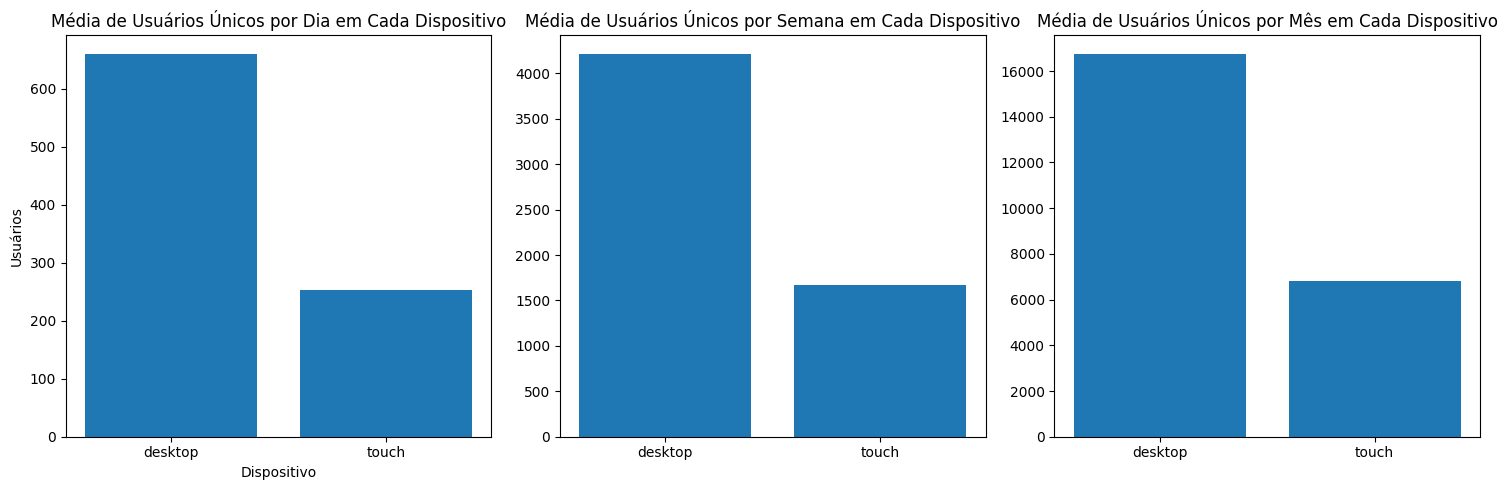

In [168]:
# Criando um gráfico lado a lado dos dispositivos por dia, semana e mês
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gráfico 1 - no axes[0]
axes[0].bar(dau_device.index, dau_device.values)
axes[0].set_title('Média de Usuários Únicos por Dia em Cada Dispositivo')
axes[0].set_xlabel('Dispositivo')
axes[0].set_ylabel('Usuários')

# Gráfico 2 - no axes[1]
axes[1].bar(wau_device.index, wau_device.values)
axes[1].set_title('Média de Usuários Únicos por Semana em Cada Dispositivo')

# Gráfico 3 - no axes[2]
axes[2].bar(mau_device.index, mau_device.values)
axes[2].set_title('Média de Usuários Únicos por Mês em Cada Dispositivo')

plt.tight_layout()
plt.show()

Verificamos que o dispositivo desktop tem mais usuários que o dispositivo touch, sendo os usuários diários do desktop em torno de 659 e de touch em torno de 252. Ademais, a quantidade de usuários semanais do desktop é em torno de 4208 e o de touch é em torno de 1666. Em relação aos usuários mensais do desktop, encontramos uma média de 16725, enquanto o de touch é em torno de 6826. Dessa forma, podemos concluir que o dispositivo desktop possui em torno de 2,5 vezes mais usuários que touch, tanto diariamente quanto semanalmente e mensalmente. Sendo assim, pode valer a pena priorizar a experiência desktop na plataforma e investigar por que o touch tem menos usuários, por exemplo, se a experiência mobile é menos intuitiva, se há problemas de performance, ou se o público-alvo da plataforma naturalmente prefere desktop.

In [169]:
# Calculando o Sticky Factor
sticky_factor_devices = (dau_device / mau_device) * 100
print(sticky_factor_devices)

device
desktop    3.941691
touch      3.694428
Name: uid, dtype: float64


In [170]:
# Calculando a quantidade de sessões por dia
avg_daily_sessions = visits_df.groupby('session_day').agg({'uid': 'count'}).mean()
print(avg_daily_sessions)

uid    987.362637
dtype: float64


In [171]:
# Calculando o comprimento de cada sessão
visits_df['session_duration_sec'] = (visits_df['end_ts'] - visits_df['start_ts']).dt.total_seconds()
print(visits_df['session_duration_sec'])

0         1080.0
1         1680.0
2            0.0
3         1440.0
4            0.0
           ...  
359395      19.0
359396      19.0
359397      19.0
359398      19.0
359399      19.0
Name: session_duration_sec, Length: 359400, dtype: float64


In [172]:
# Calculando o comprimento médio das sessões
mean_session_duration = visits_df['session_duration_sec'].mean()
print(mean_session_duration)

643.0256872565387


Podemos observar algumas sessões com duração de 0 segundos. Por isso, serão calculadas a quantidade delas.

In [173]:
# Verificando a quantidade de sessões que tem duração de 0 segundos
duration_zero = visits_df[visits_df['session_duration_sec'] == 0].shape[0]
print(duration_zero)

35794


Descobrimos que existem 35.794 sessões com duração de 0 segundos. Isso é bastante significativo, já que representa cerca de 10% dos dados. Sessões de 0 segundos provavelmente representam erros de registro ou usuários que entraram e saíram imediatamente, não sendo sessões reais. Por isso, é melhor que sejam removidos os dados com duração da sessão de 0 segundos, já que eles tão interferindo na média do comprimento das sessões.

In [174]:
# Encontrando as sessões com duração diferente de 0 segundos
valid_sessions = visits_df[visits_df['session_duration_sec'] != 0]
print(valid_sessions)

         device              end_ts source_id            start_ts  \
0         touch 2017-12-20 17:38:00         4 2017-12-20 17:20:00   
1       desktop 2018-02-19 17:21:00         2 2018-02-19 16:53:00   
3       desktop 2018-05-20 11:23:00         9 2018-05-20 10:59:00   
5       desktop 2017-09-03 21:36:00         5 2017-09-03 21:35:00   
6       desktop 2018-01-30 12:09:00         1 2018-01-30 11:13:00   
...         ...                 ...       ...                 ...   
359395  desktop 2017-07-29 19:07:19         2 2017-07-29 19:07:00   
359396    touch 2018-01-25 17:38:19         1 2018-01-25 17:38:00   
359397  desktop 2018-03-03 10:12:19         4 2018-03-03 10:12:00   
359398  desktop 2017-11-02 10:12:19         5 2017-11-02 10:12:00   
359399    touch 2017-09-10 13:13:19         2 2017-09-10 13:13:00   

                         uid session_day  session_week  session_month  \
0       16879256277535980062  2017-12-20            51             12   
1         104060357244891

In [175]:
# Calculando o comprimento médio das sessões após a remoção das sessões com duração de 0 segundos
mean_valid_sessions = valid_sessions['session_duration_sec'].mean()
print(mean_valid_sessions)

714.1506399757731


Após a remoção das sessões com duração de 0 segundos, percebemos uma diferença da média do comprimento das sessões de 643 para em torno de 714, o que é uma grande diferença. Além disso, na distribuição foram observados muitos outliers em relação ao comprimento das sessões. Dessa forma, a melhor escolha para esse caso é a mediana, já que não é afetada pelos valores extremos (como sessões muito longas) e representa o valor do meio da distribuição, ou seja, metade das sessões dura menos que esse valor e metade dura mais.

In [176]:
# Calculando a mediana do comprimento das sessões
median_valid_sessions = valid_sessions['session_duration_sec'].median()
print(median_valid_sessions)

360.0


Após o cálculo da mediana foi encontrada uma diferença discrepante em relação à média, sendo a média de 714 e a mediana de 360.

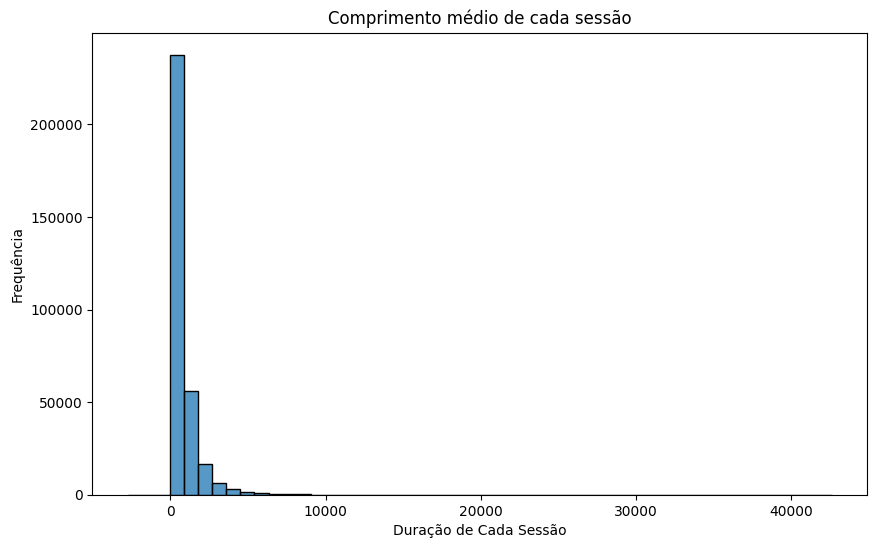

In [177]:
# Criando um histograma para o comprimento médio das sessões
plt.figure(figsize=(10, 6))
sns.histplot(data=valid_sessions, x='session_duration_sec', bins=50)
plt.title('Comprimento médio de cada sessão')
plt.xlabel('Duração de Cada Sessão')
plt.ylabel('Frequência')
plt.show()

Por meio do histograma do comprimento médio das sessões, podemos confirmar o que já havia sido observado nos cálculos. A distribuição dos dados é assimétrica, sendo que a maioria das sessões está concentrada em valores baixos de duração, contendo também valores muito altos que inflam a média. O cálculo da média e mediana confirmaram isso, já que a média apresentada antes da remoção das sessões com duração 0 foi de 643, após isso foi para 714. A mediana encontrada foi 360, uma diferença de 354 segundos em relação à média após a remoção das durações de 0 segundos, o que confirma a assimetria. Dessa forma, como a distribuição é assimétrica, com uma cauda longa para a direita (assimetria positiva), faz mais sentido considerarmos a mediana, já que ela representa melhor os valores reais das durações das sessões.

In [178]:
# Encontrando a primeira visita de cada usuário
first_visit_per_user = valid_sessions.groupby('uid')['start_ts'].min().reset_index()
print(first_visit_per_user)

                         uid            start_ts
0             11863502262781 2018-03-01 17:27:00
1             49537067089222 2018-02-06 15:55:00
2            297729379853735 2017-06-07 18:47:00
3            313578113262317 2017-09-18 22:49:00
4            325320750514679 2017-09-30 14:29:00
...                      ...                 ...
207046  18446316582013423015 2018-02-26 10:14:00
207047  18446403737806311543 2017-11-30 03:36:00
207048  18446556406699109058 2018-01-01 16:29:00
207049  18446621818809592527 2017-12-27 13:27:00
207050  18446676030785672386 2017-10-04 16:01:00

[207051 rows x 2 columns]


In [179]:
# Criando a coluna cohort no DataFrame first_visit_per_user
first_visit_per_user['cohort'] = first_visit_per_user['start_ts'].dt.to_period('M')
print(first_visit_per_user)

                         uid            start_ts   cohort
0             11863502262781 2018-03-01 17:27:00  2018-03
1             49537067089222 2018-02-06 15:55:00  2018-02
2            297729379853735 2017-06-07 18:47:00  2017-06
3            313578113262317 2017-09-18 22:49:00  2017-09
4            325320750514679 2017-09-30 14:29:00  2017-09
...                      ...                 ...      ...
207046  18446316582013423015 2018-02-26 10:14:00  2018-02
207047  18446403737806311543 2017-11-30 03:36:00  2017-11
207048  18446556406699109058 2018-01-01 16:29:00  2018-01
207049  18446621818809592527 2017-12-27 13:27:00  2017-12
207050  18446676030785672386 2017-10-04 16:01:00  2017-10

[207051 rows x 3 columns]


In [180]:
# Unindo os DataFrames valid_sessions e first_visit_per_user pela coluna uid
cohort_sessions = valid_sessions.merge(first_visit_per_user, on='uid', how='left', suffixes=('_session', '_first_visit'))
print(cohort_sessions)

         device              end_ts source_id    start_ts_session  \
0         touch 2017-12-20 17:38:00         4 2017-12-20 17:20:00   
1       desktop 2018-02-19 17:21:00         2 2018-02-19 16:53:00   
2       desktop 2018-05-20 11:23:00         9 2018-05-20 10:59:00   
3       desktop 2017-09-03 21:36:00         5 2017-09-03 21:35:00   
4       desktop 2018-01-30 12:09:00         1 2018-01-30 11:13:00   
...         ...                 ...       ...                 ...   
323601  desktop 2017-07-29 19:07:19         2 2017-07-29 19:07:00   
323602    touch 2018-01-25 17:38:19         1 2018-01-25 17:38:00   
323603  desktop 2018-03-03 10:12:19         4 2018-03-03 10:12:00   
323604  desktop 2017-11-02 10:12:19         5 2017-11-02 10:12:00   
323605    touch 2017-09-10 13:13:19         2 2017-09-10 13:13:00   

                         uid session_day  session_week  session_month  \
0       16879256277535980062  2017-12-20            51             12   
1         104060357244891

In [181]:
# Criando a coluna month com o período da sessão em meses
cohort_sessions['month'] = cohort_sessions['start_ts_session'].dt.to_period('M')

In [182]:
# Calculando a frequência com que os usuários voltam
cohort_sessions['age'] = cohort_sessions['month'] - cohort_sessions['cohort']
cohort_sessions['age'] = cohort_sessions['age'].apply(lambda x: x.n)
print(cohort_sessions[['cohort', 'month', 'age']].head(10))

    cohort    month  age
0  2017-12  2017-12    0
1  2018-02  2018-02    0
2  2018-03  2018-05    2
3  2017-09  2017-09    0
4  2017-06  2018-01    7
5  2017-11  2017-11    0
6  2017-07  2017-07    0
7  2017-11  2017-11    0
8  2017-07  2017-07    0
9  2018-01  2018-01    0


In [183]:
# Agrupando os dados por cohort e age e descobrindo quantos usuários únicos de cada coorte ainda estavam ativos em cada mês de vida
cohort_age = cohort_sessions.groupby(['cohort', 'age']).agg({'uid': 'nunique'}).reset_index()
print(cohort_age )

     cohort  age    uid
0   2017-06    0  11885
1   2017-06    1    900
2   2017-06    2    606
3   2017-06    3    710
4   2017-06    4    777
..      ...  ...    ...
73  2018-03    1    766
74  2018-03    2    480
75  2018-04    0  14215
76  2018-04    1    675
77  2018-05    0  13828

[78 rows x 3 columns]


In [184]:
# Filtrando as linhas onde age é igual a 0 e selecionando as colunas cohort e uid
age_zero = cohort_age[cohort_age['age'] == 0][['cohort', 'uid']]
print(age_zero)

     cohort    uid
0   2017-06  11885
12  2017-07  11825
23  2017-08   9214
33  2017-09  15125
42  2017-10  23538
50  2017-11  24852
57  2017-12  23030
63  2018-01  20573
68  2018-02  20173
72  2018-03  18793
75  2018-04  14215
77  2018-05  13828


In [185]:
# Unindo os DataFrames cohort_age e age_zero pela coluna cohort
cohort_retention = cohort_age.merge(age_zero , on='cohort', how='left', suffixes=('_cohort_age', '_age_zero'))
print(cohort_retention)

     cohort  age  uid_cohort_age  uid_age_zero
0   2017-06    0           11885         11885
1   2017-06    1             900         11885
2   2017-06    2             606         11885
3   2017-06    3             710         11885
4   2017-06    4             777         11885
..      ...  ...             ...           ...
73  2018-03    1             766         18793
74  2018-03    2             480         18793
75  2018-04    0           14215         14215
76  2018-04    1             675         14215
77  2018-05    0           13828         13828

[78 rows x 4 columns]


In [186]:
# Calculando a taxa de retenção
retention_rate = (cohort_retention['uid_cohort_age'] / cohort_retention['uid_age_zero'])* 100
print(retention_rate)

0     100.000000
1       7.572570
2       5.098864
3       5.973917
4       6.537653
         ...    
73      4.075986
74      2.554142
75    100.000000
76      4.748505
77    100.000000
Length: 78, dtype: float64


In [187]:
# Adicionando a coluna retention_rate ao DataFrame cohort_retention
cohort_retention['retention_rate'] = retention_rate
print(cohort_retention)

     cohort  age  uid_cohort_age  uid_age_zero  retention_rate
0   2017-06    0           11885         11885      100.000000
1   2017-06    1             900         11885        7.572570
2   2017-06    2             606         11885        5.098864
3   2017-06    3             710         11885        5.973917
4   2017-06    4             777         11885        6.537653
..      ...  ...             ...           ...             ...
73  2018-03    1             766         18793        4.075986
74  2018-03    2             480         18793        2.554142
75  2018-04    0           14215         14215      100.000000
76  2018-04    1             675         14215        4.748505
77  2018-05    0           13828         13828      100.000000

[78 rows x 5 columns]


In [188]:
# Criando uma tabela pivot para mostrar a taxa de retenção por coorte
pivot_table_cohort = cohort_retention.pivot_table(index='cohort', columns='age', values='retention_rate', aggfunc='mean')
print(pivot_table_cohort)

age         0         1         2         3         4         5         6   \
cohort                                                                       
2017-06  100.0  7.572570  5.098864  5.973917  6.537653  6.748002  5.771981   
2017-07  100.0  5.454545  5.040169  5.564482  5.665962  4.651163  4.405920   
2017-08  100.0  7.445192  6.045149  6.045149  4.797048  4.145865  3.624919   
2017-09  100.0  8.357025  6.776860  4.932231  3.808264  3.695868  3.537190   
2017-10  100.0  7.812898  5.081145  3.781120  3.364772  3.118362  2.077492   
2017-11  100.0  7.818284  4.273298  3.782392  3.263319  2.172863  2.060196   
2017-12  100.0  5.466782  3.651759  3.017803  1.945289  1.771602       NaN   
2018-01  100.0  5.779420  3.781656  2.435231  1.924853       NaN       NaN   
2018-02  100.0  5.656075  2.428989  1.918406       NaN       NaN       NaN   
2018-03  100.0  4.075986  2.554142       NaN       NaN       NaN       NaN   
2018-04  100.0  4.748505       NaN       NaN       NaN       NaN

<AxesSubplot:title={'center':'Taxa de Retenção de Usuários por Coorte e Mês de Vida (%)'}, xlabel='age', ylabel='cohort'>

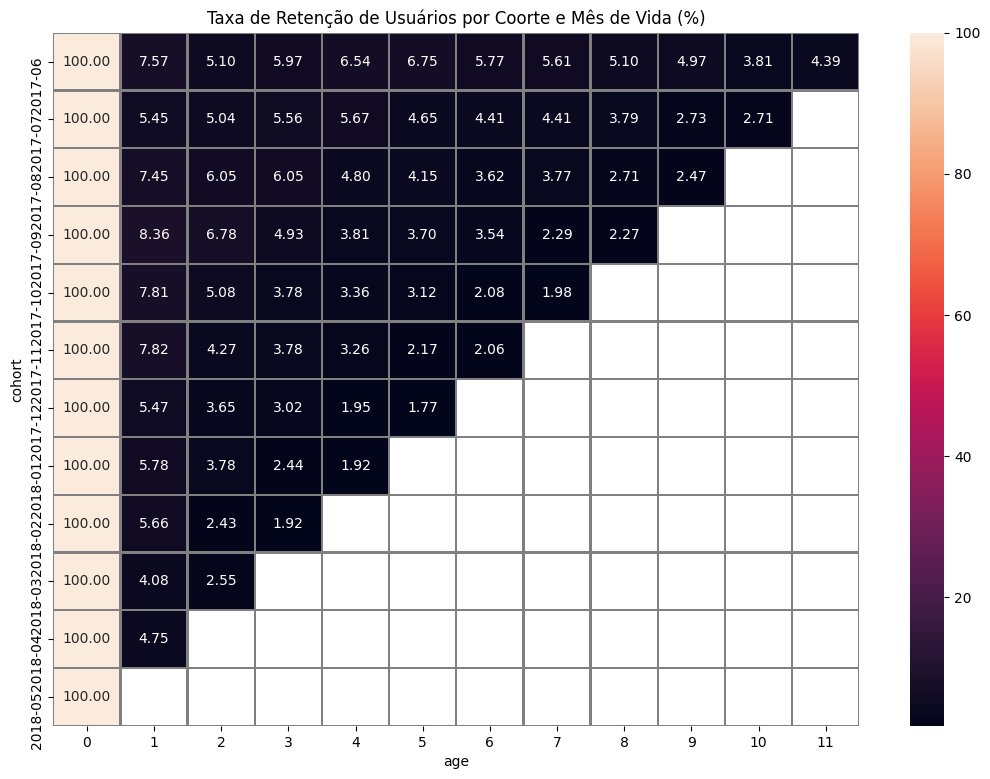

In [189]:
# Criando um heatmap para mostrar a taxa de retenção por coorte e mês de vida
plt.figure(figsize=(13, 9)) 
plt.title('Taxa de Retenção de Usuários por Coorte e Mês de Vida (%)') 
sns.heatmap(pivot_table_cohort, annot=True, fmt='.2f', linewidths=1, linecolor='gray')

No heatmap acima, na coluna age = 1 a primeira coorte (2017-06) é de 7.57%, enquanto a última coorte (2018-04) é de 4.75%. Podemos observar uma queda geral na taxa de retenção ao longo do tempo. Dessa forma, o heatmap sugere que as coortes mais recentes possuem taxas de retenção menores que as mais antigas, sendo por exemplo age = 2 com a taxa de retenção mais antiga de 5.10% e a mais recente de 2.55%. Assim como a coluna age = 3, com taxa de retenção mais antiga de 5.97% e a mais recente de 1.92%. Nas colunas subsequentes observamos o mesmo padrão de diminuição da taxa de retenção. Isso pode sugerir que os usuários mais recentes estão menos engajados que os usuários mais antigos. Porém, não podemos afirmar isso, já que as coortes mais recentes têm menos tempo de existência no dataset (por exemplo, a coorte 2018-04 só tem dados de 1 mês de vida, enquanto a 2017-06 tem dados de 11 meses), o que influencia no valor mostrado em relação à taxa de retenção. Por isso, a comparação direta entre coortes mais antigas e mais recentes deve ser feita com cautela e é menos conclusiva. Em relação à uma mesma coorte, o heatmap sugere queda na taxa de retenção, já que em 2017-06, por exemplo, em age = 1 a taxa de retenção é de 7.57% e em age = 11 a taxa de retenção é de 4.39%. O mesmo ocorre nas datas subsequentes, olhando a linha correspondente de cada data vemos uma possível queda na taxa de retenção. A data de 2017-06 sugere um aumento da taxa de retenção de age = 2 até age = 5 (de 5.10% para 6.75%), mas a partir da age = 6 a taxa de retenção volta a cair (5.77%). Ademais, em 2017-07 há um possível aumento a partir de age = 2 (5.04%) até 5.67% referente à age = 4, e a partir de age = 5 a taxa de retenção volta a cair (4.65%). Esses aumentos temporários poderão ser investigados com a análise de marketing. Nas outras datas podemos observar uma possível diminuição da taxa de retenção desde age = 1.

<div class="alert alert-block alert-success">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Boa análise de retenção por coorte com heatmap, e a leitura da queda de retenção já a partir do primeiro mês. Etapa de produto bem resolvida.
</div>

Em relação à análise de produto, a partir do cálculo de dau_total, wau_total e mau_total descobrimos que há em média 908 usuários únicos por dia. Em relação aos usuários únicos por semana, encontramos uma média de 5825. Além disso, concluímos que há em média 23228 usuários únicos por mês. Verificamos que o dispositivo desktop tem mais usuários que o dispositivo touch, sendo os usuários diários do desktop em torno de 659 e de touch em torno de 252. Ademais, a quantidade de usuários semanais do desktop é em torno de 4208 e o de touch é em torno de 1666. Em relação aos usuários mensais do desktop, encontramos uma média de 16725, enquanto o de touch é em torno de 6826. Dessa forma, podemos concluir que o dispositivo desktop possui em torno de 2,5 vezes mais usuários que touch, tanto diariamente quanto semanalmente e mensalmente. Sendo assim, pode valer a pena priorizar a experiência desktop na plataforma e investigar por que o touch tem menos usuários, por exemplo, se a experiência mobile é menos intuitiva, se há problemas de performance, ou se o público-alvo da plataforma naturalmente prefere desktop.
Por meio do cálculo do Sticky Factor, concluímos que de todos os usuários mensais do desktop, cerca de 3.94% voltam todos os dias, enquanto que dos usuários mensais do touch, cerca de 3.69% voltam todos os dias. Essa diferença pequena mostra que, no geral, os usuários de ambos os dispositivos voltam com frequência parecida. Um Sticky Factor em torno de 3.69% e 3.94% é considerado baixo para um produto digital, já que significa que de cada 100 usuários mensais, em média apenas 4 voltam diariamente.
Foi calculada também uma média de 987 sessões por dia. 
Em relação ao comprimento das sessões, foi observada a existência de 35794 sessões com duração de 0 segundos, o que é significativo, já que representa 10% dos dados e dessa forma afeta o cálculo do comprimento médio das sessões. Por isso, foi feito um DataFrame separado sem as sessões com duração de 0 segundos para que sejam feitas comparações. Após esse remoção, encontramos a média de duração da sessão em torno de 714 segundos, enquanto que antes de remover as sessões com duração de 0 segundos, essa média era em torno de 643 segundos.
A existência de comprimento de sessão com duração de 0 segundos pode ser por possíveis falhas nas sessões, além de usuários que entraram e saíram imediatamente. 
Além disso, verificamos no histograma de comprimento das sessões que a maioria das sessões está concentrada em valores baixos de duração, contendo também valores muito altos que inflam a média. O cálculo da média e mediana confirmaram isso, já que a média apresentada antes da remoção das sessões com duração 0 foi de 643 segundos, após isso foi para 714 segundos. A mediana encontrada foi 360 segundos, uma diferença de 354 segundos em relação à média após a remoção das durações de 0 segundos, o que confirma a assimetria. Dessa forma, como a distribuição é assimétrica, com uma cauda longa para a direita (assimetria positiva), faz mais sentido considerarmos a mediana, já que ela representa melhor os valores reais das durações das sessões.
Em relação à taxa de retenção, conforme abordado na conclusão do heatmap, observamos que para uma mesma coorte, o heatmap sugere queda na taxa de retenção ao compararmos age = 1 e age = 11. Isso pode ser observado em cada data, ou seja, em cada coorte. Essa queda na taxa de retenção em uma mesma coorte pode indicar insatisfação dos usuários. Ademais, observamos aumentos temporários na coorte 2017-06 em age = 2 a age = 5 (5.10% para 6.75%) e um aumento temporário também na coorte 2017-07 em age = 2 a age = 4 (5.04% para 5.67%). Esses aumentos temporários serão investigados na análise de marketing.

# 2. Vendas

In [190]:
# Encontrando o primeiro pedido de cada usuário
first_orders = orders_df.groupby('uid')['buy_ts'].min().reset_index()
print(first_orders)

                        uid              buy_ts
0           313578113262317 2018-01-03 21:51:00
1          1575281904278712 2017-06-03 10:13:00
2          2429014661409475 2017-10-11 18:33:00
3          2464366381792757 2018-01-28 15:54:00
4          2551852515556206 2017-11-24 10:14:00
...                     ...                 ...
36518  18445147675727495770 2017-11-24 09:03:00
36519  18445407535914413204 2017-09-22 23:55:00
36520  18445601152732270159 2018-03-26 22:54:00
36521  18446156210226471712 2018-02-18 19:34:00
36522  18446167067214817906 2017-10-17 10:16:00

[36523 rows x 2 columns]


In [191]:
# Unindo os DataFrames first_visit_per_user e first_orders para combinar a primeira visita de cada usuário com o primeiro pedido deles
first_visit_first_order = first_visit_per_user.merge(first_orders, on='uid', how='left')
print(first_visit_first_order)

                         uid            start_ts   cohort              buy_ts
0             11863502262781 2018-03-01 17:27:00  2018-03                 NaT
1             49537067089222 2018-02-06 15:55:00  2018-02                 NaT
2            297729379853735 2017-06-07 18:47:00  2017-06                 NaT
3            313578113262317 2017-09-18 22:49:00  2017-09 2018-01-03 21:51:00
4            325320750514679 2017-09-30 14:29:00  2017-09                 NaT
...                      ...                 ...      ...                 ...
207046  18446316582013423015 2018-02-26 10:14:00  2018-02                 NaT
207047  18446403737806311543 2017-11-30 03:36:00  2017-11                 NaT
207048  18446556406699109058 2018-01-01 16:29:00  2018-01                 NaT
207049  18446621818809592527 2017-12-27 13:27:00  2017-12                 NaT
207050  18446676030785672386 2017-10-04 16:01:00  2017-10                 NaT

[207051 rows x 4 columns]


In [192]:
# Encontrando apenas os usuários que fizeram pelo menos uma compra
valid_buy = first_visit_first_order[first_visit_first_order['buy_ts'].notna()].copy()
print(valid_buy)

                         uid            start_ts   cohort              buy_ts
3            313578113262317 2017-09-18 22:49:00  2017-09 2018-01-03 21:51:00
20          1575281904278712 2017-06-03 10:13:00  2017-06 2017-06-03 10:13:00
32          2429014661409475 2017-10-11 17:14:00  2017-10 2017-10-11 18:33:00
33          2464366381792757 2018-01-27 20:10:00  2018-01 2018-01-28 15:54:00
35          2551852515556206 2017-11-24 10:14:00  2017-11 2017-11-24 10:14:00
...                      ...                 ...      ...                 ...
207000  18442290965339407211 2018-02-05 19:35:00  2018-02 2018-02-05 19:39:00
207028  18445407535914413204 2017-09-22 23:48:00  2017-09 2017-09-22 23:55:00
207033  18445601152732270159 2017-08-07 11:51:00  2017-08 2018-03-26 22:54:00
207044  18446156210226471712 2017-11-07 10:01:00  2017-11 2018-02-18 19:34:00
207045  18446167067214817906 2017-10-17 10:05:00  2017-10 2017-10-17 10:16:00

[36081 rows x 4 columns]


In [193]:
# Calculando em quanto tempo as pessoas começam a comprar a partir da primeira visita
valid_buy['conversion_time'] = (valid_buy['buy_ts'] - valid_buy['start_ts']).dt.days
print(valid_buy['conversion_time'])

3         106
20          0
32          0
33          0
35          0
         ... 
207000      0
207028      0
207033    231
207044    103
207045      0
Name: conversion_time, Length: 36081, dtype: int64


In [194]:
# Calculando a média de tempo entre o momento da primeira visita e a primeira compra
mean_conversion_time = valid_buy['conversion_time'].mean()
print(mean_conversion_time)

15.279315983481611


In [195]:
# Calculando o número de usuários únicos que fizeram pelo menos uma compra e por coorte
unique_user_buy_per_cohort = valid_buy.groupby('cohort').agg({'uid': 'nunique'})
print(unique_user_buy_per_cohort)

          uid
cohort       
2017-06  2798
2017-07  2399
2017-08  1670
2017-09  3007
2017-10  4602
2017-11  4210
2017-12  4030
2018-01  3081
2018-02  3204
2018-03  2854
2018-04  1891
2018-05  2335


In [196]:
# Calculando o número total de usuários únicos que visitaram o site e por coorte
unique_user_per_cohort = first_visit_per_user.groupby('cohort').agg({'uid': 'nunique'})
print(unique_user_per_cohort)

           uid
cohort        
2017-06  11885
2017-07  11825
2017-08   9214
2017-09  15125
2017-10  23538
2017-11  24852
2017-12  23030
2018-01  20573
2018-02  20173
2018-03  18793
2018-04  14215
2018-05  13828


In [197]:
# Calculando a taxa de conversão
conversion_rate = (unique_user_buy_per_cohort / unique_user_per_cohort)* 100
print(conversion_rate)

               uid
cohort            
2017-06  23.542280
2017-07  20.287526
2017-08  18.124593
2017-09  19.880992
2017-10  19.551364
2017-11  16.940286
2017-12  17.498914
2018-01  14.975939
2018-02  15.882615
2018-03  15.186506
2018-04  13.302849
2018-05  16.886028


In [198]:
# Contando o número de pedidos por cliente
orders_df['orders_per_client'] = orders_df.groupby('uid')['buy_ts'].transform('count')
print(orders_df['orders_per_client'])

0        1
1        1
2        1
3        1
4        1
        ..
50410    1
50411    1
50412    1
50413    1
50414    1
Name: orders_per_client, Length: 50415, dtype: int64


In [199]:
# Criando a coluna order_month com o período da sessão em meses
orders_df['order_month'] = orders_df['buy_ts'].dt.to_period('M')
print(orders_df['order_month'])

0        2017-06
1        2017-06
2        2017-06
3        2017-06
4        2017-06
          ...   
50410    2018-05
50411    2018-05
50412    2018-05
50413    2018-05
50414    2018-06
Name: order_month, Length: 50415, dtype: period[M]


In [200]:
# Contando o número de pedidos para cada cliente e mês
orders_df['order_client_month'] = orders_df.groupby(['uid', 'order_month'])['buy_ts'].transform('count')
print(orders_df['order_client_month'])

0        1
1        1
2        1
3        1
4        1
        ..
50410    1
50411    1
50412    1
50413    1
50414    1
Name: order_client_month, Length: 50415, dtype: int64


In [201]:
# Calculando a média do número de pedidos para cada cliente e mês
mean_order_client_month = orders_df['order_client_month'].mean()
print(mean_order_client_month)

2.7889913716155905


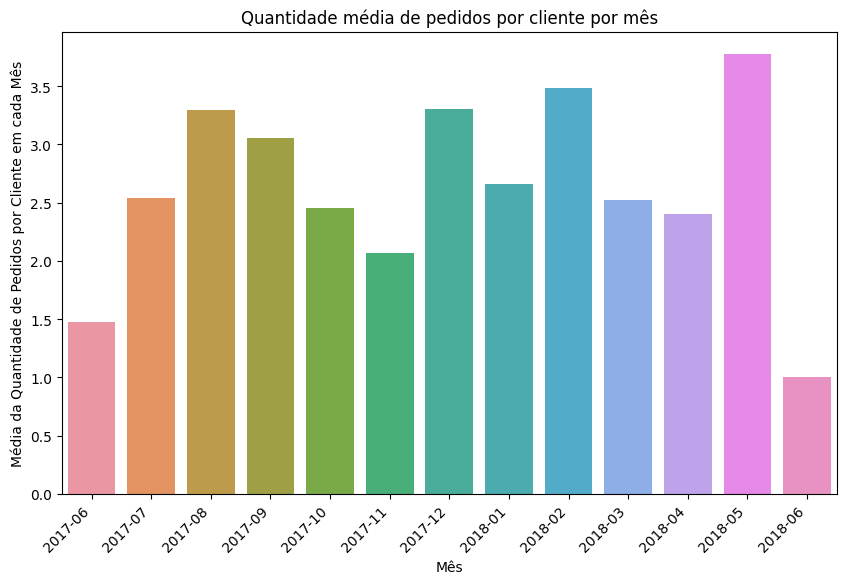

In [202]:
# Construindo um gráfico de barras que mostra a média da quantidade de pedidos por cliente em cada mês
mean_per_month = orders_df.groupby('order_month')['order_client_month'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=mean_per_month, x='order_month', y='order_client_month')
plt.xticks(rotation=45, ha='right')
plt.title('Quantidade média de pedidos por cliente por mês')
plt.xlabel('Mês')
plt.ylabel('Média da Quantidade de Pedidos por Cliente em cada Mês')
plt.show()

Por meio dos cálculos acima, concluímos que a média geral do número de pedidos para cada cliente e mês foi em torno de 2.79. O gráfico de barras mostra que no mês 5 de 2018 houve o maior pico de pedidos (em torno de 3.75 pedidos). Observamos que logo em seguida, no mês 6 de 2018 houve uma queda brusca no número de pedidos (em torno de 1.0), sendo esse mês o menor de todos. Isso pode ser explicado também porque o dataset vai até junho/2018, então há menos dados nesse mês, o que pode explicar a queda brusca. O segundo mês com maior número de pedidos foi o mês 2 de 2018 (em torno de 3.5 pedidos). O mês 12 e o mês 8 em 2017 foram parecidos (em torno de 3.3 pedidos). O gráfico ilustra um comportamento geral instável, podendo ser devido à sazonalidade ou variações no engajamento dos clientes, o que será investigado na análise de marketing.

In [203]:
# Calculando o volume médio de uma compra
mean_revenue = orders_df['revenue'].mean()
print(mean_revenue)

4.999646930477041


In [204]:
# Calculando o total de receita por usuário
total_revenue_per_user = orders_df.groupby('uid')['revenue'].sum()
print(total_revenue_per_user)

uid
313578113262317          0.55
1575281904278712         3.05
2429014661409475        73.33
2464366381792757         2.44
2551852515556206        10.99
                        ...  
18445147675727495770     3.05
18445407535914413204     0.88
18445601152732270159     4.22
18446156210226471712     9.78
18446167067214817906     7.94
Name: revenue, Length: 36523, dtype: float64


In [205]:
# Calculando a média do total de receita por usuário
mean_revenue_per_user = total_revenue_per_user.mean()
print(mean_revenue_per_user)

6.901327930345262


In [206]:
# Unindo os DataFrames orders_df e first_visit_per_user 
orders_first_visits = orders_df.merge(first_visit_per_user, on='uid', how='left')
print(orders_first_visits)

                   buy_ts  revenue                   uid  orders_per_client  \
0     2017-06-01 00:10:00    17.00  10329302124590727494                  1   
1     2017-06-01 00:25:00     0.55  11627257723692907447                  1   
2     2017-06-01 00:27:00     0.37  17903680561304213844                  1   
3     2017-06-01 00:29:00     0.55  16109239769442553005                  1   
4     2017-06-01 07:58:00     0.37  14200605875248379450                  1   
...                   ...      ...                   ...                ...   
50410 2018-05-31 23:50:00     4.64  12296626599487328624                  1   
50411 2018-05-31 23:50:00     5.80  11369640365507475976                  1   
50412 2018-05-31 23:54:00     0.30   1786462140797698849                  1   
50413 2018-05-31 23:56:00     3.67   3993697860786194247                  1   
50414 2018-06-01 00:02:00     3.42     83872787173869366                  1   

      order_month  order_client_month            st

In [207]:
# Criando valid_cohort para filtrar as linhas onde cohort não é NaT
valid_cohort = orders_first_visits[orders_first_visits['cohort'].notna()].copy()

In [208]:
# Criando a coluna age que representa quantos meses se passaram entre o coorte do usuário e o mês do pedido
valid_cohort['age'] = valid_cohort['order_month'] - valid_cohort['cohort']
valid_cohort['age'] = valid_cohort['age'].apply(lambda x: x.n)

In [209]:
# Calculando a receita por coorte e age
cohort_revenue = valid_cohort.groupby(['cohort', 'age']).agg({'revenue': 'sum'}).reset_index()

In [210]:
# Unindo os DataFrames cohort_revenue e unique_user_per_cohort para calcular o número de usuários por coorte
users_per_cohort = cohort_revenue.merge(unique_user_per_cohort, on='cohort', how='left')
print(users_per_cohort)

      cohort  age   revenue    uid
0    2017-06    0   9398.64  11885
1    2017-06    1   2551.31  11885
2    2017-06    2   1393.86  11885
3    2017-06    3   3787.65  11885
4    2017-06    4   3615.56  11885
..       ...  ...       ...    ...
118  2018-05   -5      0.43  13828
119  2018-05   -4      0.24  13828
120  2018-05   -3      3.78  13828
121  2018-05    0  10415.20  13828
122  2018-05    1      3.42  13828

[123 rows x 4 columns]


Aqui podemos ver valores negativos em age, mostrando que alguns pedidos foram registrados antes da primeira visita do usuário, o que não faz sentido logicamente. Provavelmente são inconsistências nos dados. Por isso, é necessário filtrar as linhas onde age é maior ou igual a 0.

In [211]:
# Filtrando as linhas onde age é maior ou igual a 0 
users_per_cohort_valid = users_per_cohort[users_per_cohort['age'] >= 0].copy()
print(users_per_cohort_valid)

      cohort  age   revenue    uid
0    2017-06    0   9398.64  11885
1    2017-06    1   2551.31  11885
2    2017-06    2   1393.86  11885
3    2017-06    3   3787.65  11885
4    2017-06    4   3615.56  11885
..       ...  ...       ...    ...
106  2018-03    2    760.47  18793
113  2018-04    0   8085.39  14215
114  2018-04    1   1787.04  14215
121  2018-05    0  10415.20  13828
122  2018-05    1      3.42  13828

[79 rows x 4 columns]


In [212]:
# Calculando o LTV
users_per_cohort_valid['ltv'] = users_per_cohort_valid['revenue'] / users_per_cohort_valid['uid']
print(users_per_cohort_valid['ltv'])

0      0.790798
1      0.214666
2      0.117279
3      0.318692
4      0.304212
         ...   
106    0.040466
113    0.568793
114    0.125715
121    0.753196
122    0.000247
Name: ltv, Length: 79, dtype: float64


In [213]:
# Criando a tabela pivot do LTV por coorte
pivot_table_ltv_per_cohort = users_per_cohort_valid.pivot_table(index='cohort', columns='age', values='ltv', aggfunc='mean',)
print(pivot_table_ltv_per_cohort)

age            0         1         2         3         4         5         6   \
cohort                                                                          
2017-06  0.790798  0.214666  0.117279  0.318692  0.304212  0.224151  0.284462   
2017-07  0.835362  0.088790  0.092105  0.097741  0.079053  0.068990  0.054129   
2017-08  0.678125  0.107514  0.109952  0.093383  0.087179  0.054225  0.044513   
2017-09  0.806176  0.237788  0.133481  0.689792  0.084750  0.125302  0.060693   
2017-10  0.781141  0.154422  0.053016  0.043185  0.040016  0.035740  0.022520   
2017-11  0.673584  0.106421  0.052605  0.055602  0.041627  0.025585  0.025432   
2017-12  0.729140  0.073244  0.181763  0.220202  0.066696  0.075768       NaN   
2018-01  0.516978  0.090537  0.055378  0.014116  0.024847       NaN       NaN   
2018-02  0.575607  0.093512  0.033251  0.059723       NaN       NaN       NaN   
2018-03  0.651814  0.050687  0.040466       NaN       NaN       NaN       NaN   
2018-04  0.568793  0.125715 

<AxesSubplot:title={'center':'LTV por Coorte'}, xlabel='age', ylabel='cohort'>

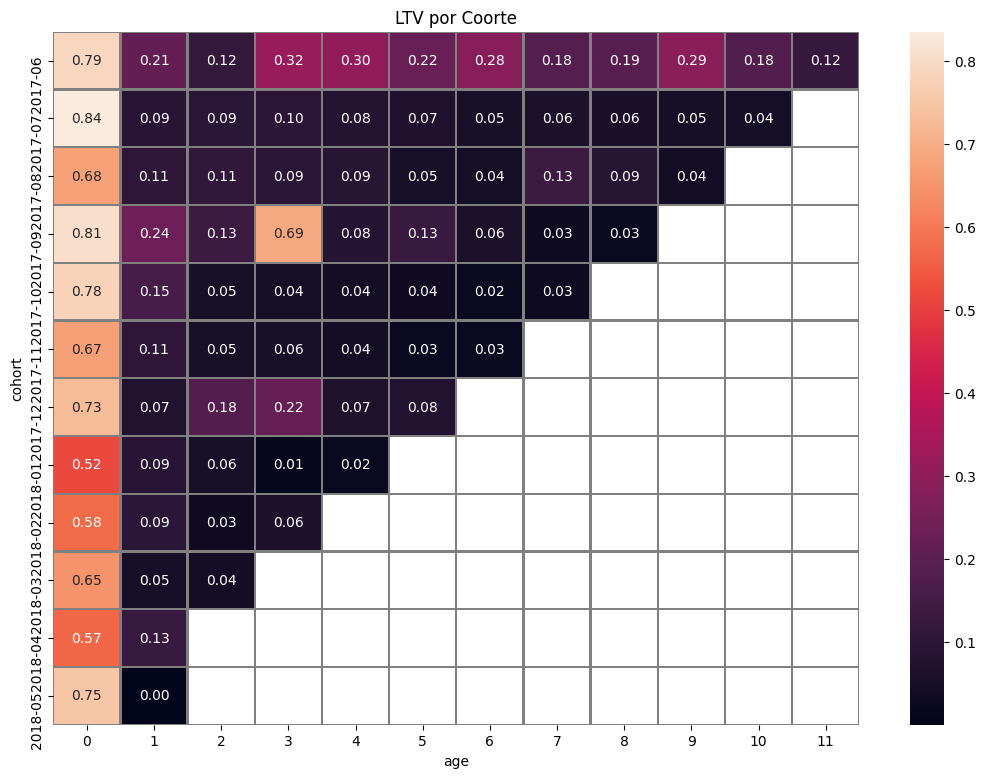

In [214]:
# Criando um heatmap para mostrar o LTV por coorte
plt.figure(figsize=(13, 9)) 
plt.title('LTV por Coorte') 
sns.heatmap(pivot_table_ltv_per_cohort, annot=True, fmt='.2f', linewidths=1, linecolor='gray')

<div class="alert alert-block alert-success">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>

LTV por coorte calculado corretamente (receita da coorte dividida pelo número de compradores) e visualizado em heatmap. 👍
</div>

Antes de fazer uma conclusão para o heatmap que representa LTV por coorte, vale mencionar a diferença discrepante na coorte 2017-09 de age = 2 para age = 3, sendo 0.13 em age = 2 e 0.69 em age = 3. Dessa forma, vale fazer um filtro para investigar esse pico.

In [215]:
# Filtrando os pedidos da coorte 2017-09 em age = 3 e verificando a receita total
filtro_09 = (valid_cohort['cohort'] == '2017-09') & (valid_cohort['age'] == 3)
resultado = valid_cohort[filtro_09]
print(resultado)

                   buy_ts  revenue                   uid  orders_per_client  \
21265 2017-12-01 09:56:00    34.22   7137696533349307614                  6   
21297 2017-12-01 11:58:00    42.78   7137696533349307614                  6   
21314 2017-12-01 12:56:00     3.67   3612974943094492246                  4   
21320 2017-12-01 13:21:00     3.67   1654277367019880014                  2   
21331 2017-12-01 14:18:00     4.58   9156947215999310287                  7   
...                   ...      ...                   ...                ...   
27295 2017-12-30 22:54:00     9.17  14784782806896063174                  1   
27303 2017-12-31 00:03:00     0.49   8282527186995232054                  1   
27305 2017-12-31 00:18:00    18.33   6410736072702849726                  1   
27377 2017-12-31 15:21:00     1.22  12393205753339584976                  3   
27462 2017-12-31 23:00:00     5.50  18253446218020150082                  3   

      order_month  order_client_month            st

In [216]:
# Verificando a distribuição da receita
print(resultado['revenue'].describe())
print(resultado['revenue'].sort_values(ascending=False).head(10))

count     272.000000
mean       38.357022
std       186.438639
min         0.030000
25%         1.530000
50%         3.670000
75%        13.005000
max      2633.280000
Name: revenue, dtype: float64
23244    2633.28
23165    1195.64
24341     604.39
21961     402.72
22769     360.55
21906     344.36
24775     337.33
25480     304.94
23483     293.03
23196     243.83
Name: revenue, dtype: float64


Obtendo um resumo estatístico da coluna revenue, verificamos que a mediana (50%) é 3.67, representando o valor típico de um pedido. Além disso, descobrimos que a média foi em torno de 38.36, sendo muito maior que a mediana. O desvio padrão encontrado foi de 186.44, o que significa uma enorme variação. Ademais, o valor máximo encontrado foi de 2633,28, um valor absurdamente alto. Isso indica claramente que há um outlier inflando a média e, consequentemente, o LTV. Dessa forma, vale a pena investigar a/as linhas com receita de 2633,28.

In [217]:
# Verificando as linhas com valor da receita de 2633.28
max_revenue = resultado[resultado['revenue'] == 2633.28]
print(max_revenue)

                   buy_ts  revenue                  uid  orders_per_client  \
23244 2017-12-10 20:17:00  2633.28  5539673724080479777                101   

      order_month  order_client_month            start_ts   cohort  age  
23244     2017-12                  49 2017-09-07 13:45:00  2017-09    3  


Encontramos o uid do usuário responsável pelo outlier, sendo esse uid de 5539673724080479777. Esse usuário fez 101 pedidos no total e 49 pedidos só no mês de dezembro de 2017, o que representa um outlier e inflaciona o LTV dessa coorte, explicando o aumento signficativo do LTV de age = 2 a age = 3 (de 0.13 para 0.69). Dessa forma, vale criar um DataFrame sem o pedido que gerou a receita de 2633.28.

In [218]:
# Criando um DataFrame sem o pedido que gerou a receita de 2633.28 (outlier)
orders_df_clean = orders_df[orders_df['uid'] != 5539673724080479777].copy()
print(orders_df_clean)

                   buy_ts  revenue                   uid  orders_per_client  \
0     2017-06-01 00:10:00    17.00  10329302124590727494                  1   
1     2017-06-01 00:25:00     0.55  11627257723692907447                  1   
2     2017-06-01 00:27:00     0.37  17903680561304213844                  1   
3     2017-06-01 00:29:00     0.55  16109239769442553005                  1   
4     2017-06-01 07:58:00     0.37  14200605875248379450                  1   
...                   ...      ...                   ...                ...   
50410 2018-05-31 23:50:00     4.64  12296626599487328624                  1   
50411 2018-05-31 23:50:00     5.80  11369640365507475976                  1   
50412 2018-05-31 23:54:00     0.30   1786462140797698849                  1   
50413 2018-05-31 23:56:00     3.67   3993697860786194247                  1   
50414 2018-06-01 00:02:00     3.42     83872787173869366                  1   

      order_month  order_client_month  
0         2

Podemos analisar no heatmap de LTV por coorte que em age = 0 (primeiro mês de cada coorte e primeira compra dos clientes) a coorte que gerou mais LTV foi 2017-07, com 0.84. A coorte de 2017-06 para age = 0 teve um LTV de 0.79 e a coorte de 2018-05 em age = 0 teve um LTV de 0.75. Em age = 1, a coorte que gerou mais LTV foi a de 2017-06, sendo de 0.21. Já a coorte de 2018-05 mostra o menor valor (0.00), sugerindo uma diminuição no LTV ao longo do tempo, ou seja, sugerindo uma diminuição do total de dinheiro que um cliente traz para a empresa, em média, ao longo de todas as suas compras.
Dessa forma, o heatmap sugere que as coortes mais recentes possuem LTV menores que as coortes mais antigas, sendo, por exemplo, em age = 2 o LTV mais antigo de 0.12 e o mais recente de 0.04. Assim como a coluna age = 3, com o LTV mais antigo de 0.32 e o mais recente de 0.06. Nas colunas subsequentes observamos também a diminuição do LTV ao longo do tempo.
Isso pode sugerir que os usuários mais recentes estão menos engajados que os usuários mais antigos. Porém, não podemos afirmar isso, já que as coortes mais recentes têm menos tempo de existência no dataset (por exemplo, a coorte 2018-05 só tem dados de 1 mês de vida, enquanto a 2017-06 tem dados de 11 meses), o que influencia no valor mostrado em relação ao LTV. Por isso, a comparação direta entre coortes mais antigas e mais recentes deve ser feita com cautela e é menos conclusiva. Em relação à uma mesma coorte, o heatmap sugere queda no LTV, já que em 2017-06, por exemplo, em age = 1 o LTV é de 0.21 e em age = 11 o LTV é de 0.12. O mesmo ocorre nas datas subsequentes, olhando a linha correspondente de cada data vemos uma possível queda do LTV. A data de 2017-06 sugere um aumento do LTV de age = 2 a age = 3 (de 0.12 para 0.32), mas a partir de age = 4 o LTV volta a cair (0.30). Ademais, em 2017-09 há um aumento significativo do LTV de age = 2 a age = 3 (de 0.13 para 0.69) e depois volta a cair bruscamente novamente (para 0.08). Descobrimos que na coorte 2019-09 em age = 3 (dezembro de 2017) um único usuário (uid: 5539673724080479777) fez 101 pedidos no total e 49 pedidos só no mês de dezembro de 2017, o que representa um outlier e inflacionou o LTV dessa coorte, explicando esse aumento signficativo do LTV de age = 2 a age = 3 (de 0.13 para 0.69). Uma receita de 2633.28 em um único mês definitivamente não representa o comportamento típico dos usuários e manter esse cliente nos dados pode distorcer as métricas, por isso foi necessário criar um DataFrame sem o pedido que gerou a receita de 2633.28. Em 2017-12 também há um aumento de age = 2 a age = 3 (0.18 a 0.22).

In [219]:
# Unindo os DataFrames orders_df_clean (DataFrame sem o outlier 2633.28) e first_visit_per_user 
orders_first_visits_clean = orders_df_clean.merge(first_visit_per_user, on='uid', how='left')

In [220]:
# Criando valid_cohort para filtrar as linhas do DataFrame sem o outlier 2633.28, onde cohort não é NaT
valid_cohort_clean = orders_first_visits_clean[orders_first_visits_clean['cohort'].notna()].copy()

In [221]:
# Criando a coluna age no DataFrame sem o outlier 2633.28, que representa quantos meses se passaram entre o coorte do usuário e o mês do pedido
valid_cohort_clean['age'] = valid_cohort_clean['order_month'] - valid_cohort_clean['cohort']
valid_cohort_clean['age'] = valid_cohort_clean['age'].apply(lambda x: x.n)

In [222]:
# Calculando a receita por coorte e age no DataFrame sem o outlier 2633.28
cohort_revenue_clean = valid_cohort_clean.groupby(['cohort', 'age']).agg({'revenue': 'sum'}).reset_index()

In [223]:
# Unindo os DataFrames cohort_revenue_clean (sem o outlier 2633.28) e unique_user_per_cohort para calcular o número de usuários por coorte
users_per_cohort_clean = cohort_revenue_clean.merge(unique_user_per_cohort, on='cohort', how='left')
print(users_per_cohort_clean)

      cohort  age   revenue    uid
0    2017-06    0   9398.64  11885
1    2017-06    1   2551.31  11885
2    2017-06    2   1393.86  11885
3    2017-06    3   3787.65  11885
4    2017-06    4   3615.56  11885
..       ...  ...       ...    ...
118  2018-05   -5      0.43  13828
119  2018-05   -4      0.24  13828
120  2018-05   -3      3.78  13828
121  2018-05    0  10415.20  13828
122  2018-05    1      3.42  13828

[123 rows x 4 columns]


In [224]:
# Filtrando as linhas onde age é maior ou igual a 0 no DataFrame sem o outlier 2633.28
users_per_cohort_valid_clean = users_per_cohort_clean[users_per_cohort_clean['age'] >= 0].copy()
print(users_per_cohort_valid_clean)

      cohort  age   revenue    uid
0    2017-06    0   9398.64  11885
1    2017-06    1   2551.31  11885
2    2017-06    2   1393.86  11885
3    2017-06    3   3787.65  11885
4    2017-06    4   3615.56  11885
..       ...  ...       ...    ...
106  2018-03    2    760.47  18793
113  2018-04    0   8085.39  14215
114  2018-04    1   1787.04  14215
121  2018-05    0  10415.20  13828
122  2018-05    1      3.42  13828

[79 rows x 4 columns]


In [225]:
# Calculando o LTV do DataFrame sem o outlier 2633.28
users_per_cohort_valid_clean['ltv'] = users_per_cohort_valid_clean['revenue'] / users_per_cohort_valid_clean['uid']
print(users_per_cohort_valid_clean['ltv'])

0      0.790798
1      0.214666
2      0.117279
3      0.318692
4      0.304212
         ...   
106    0.040466
113    0.568793
114    0.125715
121    0.753196
122    0.000247
Name: ltv, Length: 79, dtype: float64


In [226]:
# Criando a tabela pivot do LTV por coorte do DataFrame sem o outlier 2633.28
pivot_table_ltv_per_cohort_clean = users_per_cohort_valid_clean.pivot_table(index='cohort', columns='age', values='ltv', aggfunc='mean',)
print(pivot_table_ltv_per_cohort_clean)

age            0         1         2         3         4         5         6   \
cohort                                                                          
2017-06  0.790798  0.214666  0.117279  0.318692  0.304212  0.224151  0.284462   
2017-07  0.835362  0.088790  0.092105  0.097741  0.079053  0.068990  0.054129   
2017-08  0.678125  0.107514  0.109952  0.093383  0.087179  0.054225  0.044513   
2017-09  0.767935  0.237788  0.123704  0.077978  0.056933  0.048801  0.050977   
2017-10  0.781141  0.154422  0.053016  0.043185  0.040016  0.035740  0.022520   
2017-11  0.673584  0.106421  0.052605  0.055602  0.041627  0.025585  0.025432   
2017-12  0.729140  0.073244  0.181763  0.220202  0.066696  0.075768       NaN   
2018-01  0.516978  0.090537  0.055378  0.014116  0.024847       NaN       NaN   
2018-02  0.575607  0.093512  0.033251  0.059723       NaN       NaN       NaN   
2018-03  0.651814  0.050687  0.040466       NaN       NaN       NaN       NaN   
2018-04  0.568793  0.125715 

In [227]:
# Calculando o LTV acumulado ao longo do tempo do DataFrame sem o outlier 2633.28
ltv_cumsum_clean = pivot_table_ltv_per_cohort_clean.cumsum(axis=1).round(2) 
print(ltv_cumsum_clean)

age        0     1     2     3     4     5     6     7     8     9     10  \
cohort                                                                      
2017-06  0.79  1.01  1.12  1.44  1.75  1.97  2.25  2.44  2.63  2.92  3.10   
2017-07  0.84  0.92  1.02  1.11  1.19  1.26  1.32  1.38  1.43  1.49  1.53   
2017-08  0.68  0.79  0.90  0.99  1.08  1.13  1.17  1.31  1.40  1.44   NaN   
2017-09  0.77  1.01  1.13  1.21  1.26  1.31  1.36  1.39  1.42   NaN   NaN   
2017-10  0.78  0.94  0.99  1.03  1.07  1.11  1.13  1.16   NaN   NaN   NaN   
2017-11  0.67  0.78  0.83  0.89  0.93  0.96  0.98   NaN   NaN   NaN   NaN   
2017-12  0.73  0.80  0.98  1.20  1.27  1.35   NaN   NaN   NaN   NaN   NaN   
2018-01  0.52  0.61  0.66  0.68  0.70   NaN   NaN   NaN   NaN   NaN   NaN   
2018-02  0.58  0.67  0.70  0.76   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2018-03  0.65  0.70  0.74   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2018-04  0.57  0.69   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   

<AxesSubplot:title={'center':'LTV Acumulado'}, xlabel='age', ylabel='cohort'>

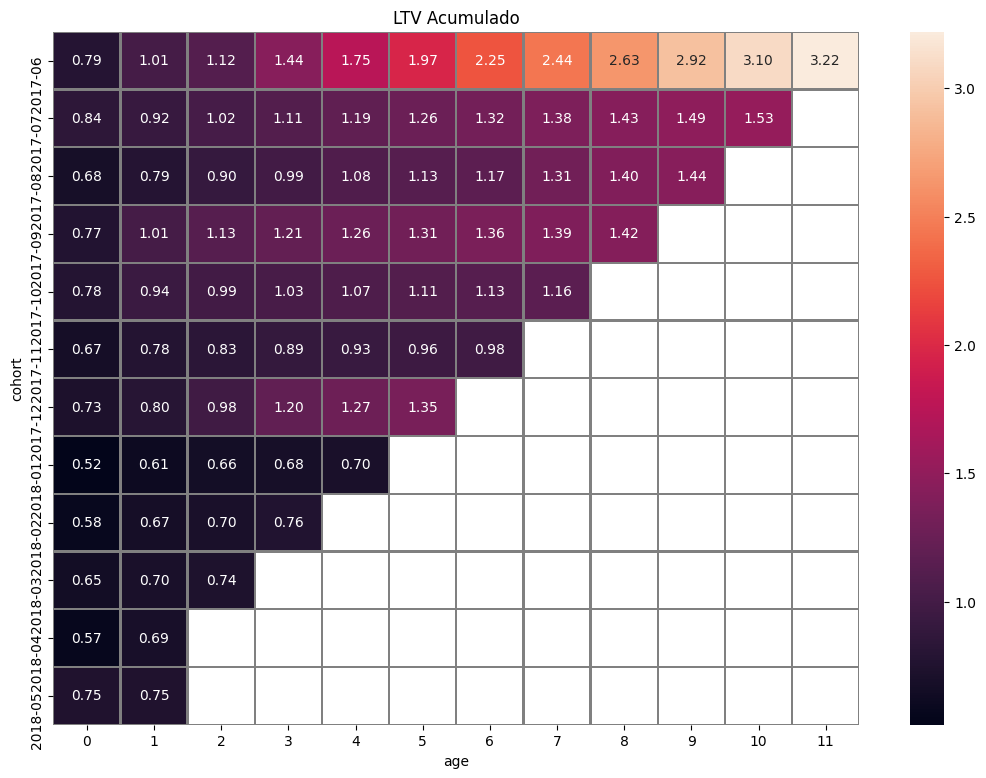

In [228]:
# Criando um heatmap para mostrar o LTV acumulado sem o outlier 2633.28 
plt.figure(figsize=(13, 9)) 
plt.title('LTV Acumulado') 
sns.heatmap(ltv_cumsum_clean, annot=True, fmt='.2f', linewidths=1, linecolor='gray')

In [229]:
# Calculando o LTV acumulado ao longo do tempo com o outlier 2633.28
ltv_cumsum = pivot_table_ltv_per_cohort.cumsum(axis=1).round(2) 
print(ltv_cumsum)

age        0     1     2     3     4     5     6     7     8     9     10  \
cohort                                                                      
2017-06  0.79  1.01  1.12  1.44  1.75  1.97  2.25  2.44  2.63  2.92  3.10   
2017-07  0.84  0.92  1.02  1.11  1.19  1.26  1.32  1.38  1.43  1.49  1.53   
2017-08  0.68  0.79  0.90  0.99  1.08  1.13  1.17  1.31  1.40  1.44   NaN   
2017-09  0.81  1.04  1.18  1.87  1.95  2.08  2.14  2.17  2.20   NaN   NaN   
2017-10  0.78  0.94  0.99  1.03  1.07  1.11  1.13  1.16   NaN   NaN   NaN   
2017-11  0.67  0.78  0.83  0.89  0.93  0.96  0.98   NaN   NaN   NaN   NaN   
2017-12  0.73  0.80  0.98  1.20  1.27  1.35   NaN   NaN   NaN   NaN   NaN   
2018-01  0.52  0.61  0.66  0.68  0.70   NaN   NaN   NaN   NaN   NaN   NaN   
2018-02  0.58  0.67  0.70  0.76   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2018-03  0.65  0.70  0.74   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2018-04  0.57  0.69   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   

<AxesSubplot:title={'center':'LTV Acumulado'}, xlabel='age', ylabel='cohort'>

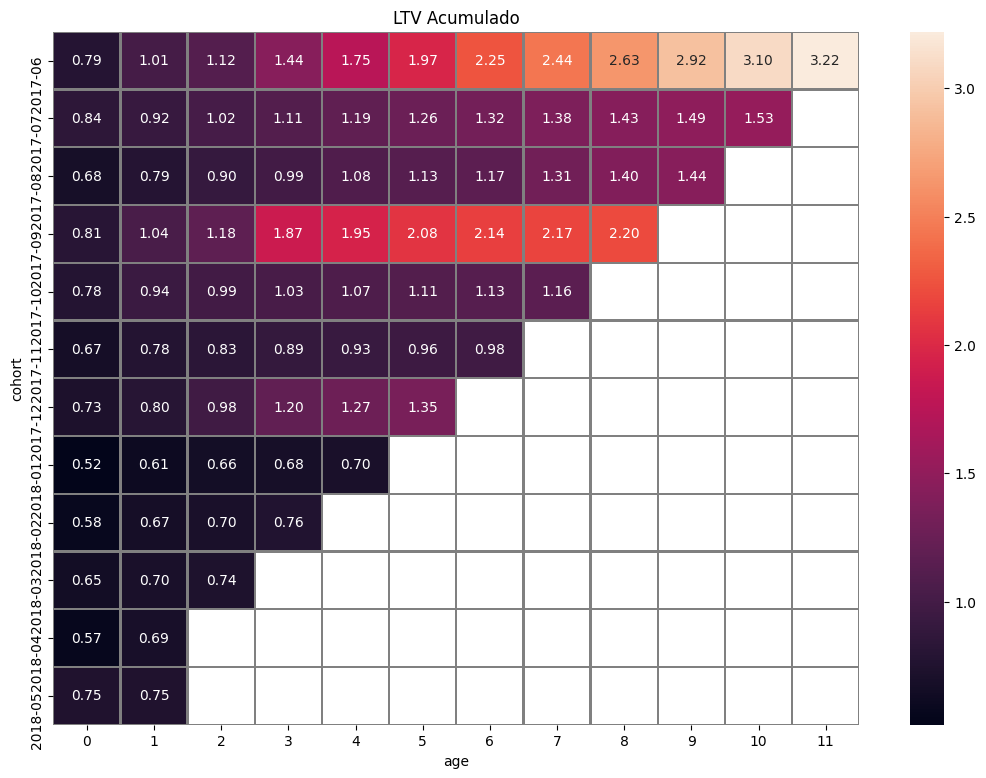

In [230]:
# Criando um heatmap para mostrar o LTV acumulado com o outlier 2633.28 
plt.figure(figsize=(13, 9)) 
plt.title('LTV Acumulado') 
sns.heatmap(ltv_cumsum, annot=True, fmt='.2f', linewidths=1, linecolor='gray')

<div class="alert alert-block alert-success">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Ótimo cuidado: você identifica e trata o outlier de receita e ainda calcula o <b>LTV acumulado</b> ao longo do tempo, com e sem o outlier. Análise de vendas completa.
</div>

Para a análise do LTV acumulado, foram feitos os heatmaps do DataFrame sem o outlier 2633.28 e com o outlier 2633.28, com o objetivo de comparar os valores. Uma receita de 2633.28 em um único mês definitivamente não representa o comportamento típico dos usuários e manter esse cliente nos dados pode distorcer as métricas. Dessa forma, analisamos que na coorte 2017-09 ao considerar a receita de 2633.28 vemos um aumento significativo no LTV acumulado de age =2 para age = 3 (1.18 para 1.87), e consequentemente inflando todos os LTV acumulados seguintes dessa coorte. Porém, ao não considerarmos a receita de 2633.28, que infla o LTV acumulado nesse período, observamos um LTV acumulado de 1.13 para 1.21 de age = 2 para age = 3, o que consequentemente não infla os LTV acumulados seguintes nessa coorte. Conforme analisado, esse não representa o comportamento típico dos usuários, sendo mais condizente à realidade considerarmos o LTV acumulado nessa coorte sem o outlier 2633.28.
Ademais, podemos analisar no heatmap de LTV acumulado que em age = 0 os valores são iguais ao do heatmap do LTV por coorte, já que é o primeiro mês e os valores ainda não acumularam. A partir de age = 1, vemos que a coorte com maior LTV acumulado é 2017-06, sendo de 1.01 e a coorte de menor LTV acumulado é 2018-05, com 0.75, sendo que nessa coorte de age = 0 a age = 1 o valor continuou o mesmo. A coorte mais recente possui menor LTV acumulado porque ela tem menos tempo no dataset (por exemplo, a coorte 2018-05 só tem dados de 1 mês de vida, enquanto a 2017-06 tem dados de 11 meses), o que influencia no valor mostrado em relação ao LTV acumulado. Por isso, a comparação direta entre coortes mais antigas e mais recentes deve ser feita com cautela e é menos conclusiva. 
Em relação à uma mesma coorte, vemos o aumento ao longo do tempo em cada uma delas, exceto para a coorte de 2018-05, que permaneceu a mesma (0.75), sugerindo que nessa coorte os clientes não compraram nada. A maior coorte acumulada foi a de 2017-06, com 3.22, mostrando um aumento significativo de age = 0 a age = 11 (0.79 para 3.22). Esse aumento significativo no LTV acumulado ao longo do tempo em relação à coorte mais antiga sugere que os clientes continuam comprando ao longo do tempo, podendo representar um potencial de receita a longo prazo. Se as outras coortes seguirem um padrão como esse podemos esperar aumento de receita. Para complementar a análise, o LTV acumulado sempre vai aumentar ou permanecer o mesmo ao longo do tempo, nunca diminuir, já que ele representa o total acumulado, feito por meio do cumsum, que sempre soma valores ao total anterior.

Em relação à análise geral das vendas, concluímos que o tempo entre a primeira visita e a primeira compra é em média de 15 dias.
A coorte com maior taxa de conversão foi a de 2017-06 (mais antiga), com em torno de 23.54, sendo a mais recente (2018-05) com uma taxa de conversão em torno de 16.89. Porém, a menor taxa de conversão não foi a da coorte mais recente, e sim a da penúltima coorte (2018-04), com essa taxa em torno de 13.30. Podemos observar que as taxas de conversão vão caindo até a coorte 2017-08 e aumenta em 2017-09 (18.12 para 19.88) e depois cai novamente até a coorte 2017-11. Em 2017-12 a taxa volta a aumentar (de 16.94 para 17.5) e cai novamente. Dessa forma, observamos que não há uma tendência fixa de aumento da taxa de conversão ao longo do tempo.
Ademais, observamos que a média geral do número de pedidos para cada cliente e mês foi em torno de 2.79. O gráfico de barras mostra que no mês 5 de 2018 houve o maior pico de pedidos (em torno de 3.75 pedidos). Observamos que logo em seguida, no mês 6 de 2018 houve uma queda brusca no número de pedidos (em torno de 1.0), sendo esse mês o menor de todos. O segundo mês com maior número de pedidos foi o mês 2 de 2018 (em torno de 3.5 pedidos). O mês 12 e o mês 8 em 2017 foram parecidos (em torno de 3.3 pedidos). O gráfico ilustra um comportamento geral instável, que pode ser explicado por meio da análise de marketing, ainda a ser realizada.
Inferimos que o valor médio gasto por pedido é em torno de 5.00. O LTV, que calcula quanto um cliente gera de receita para a empresa ao longo de toda a sua vida como cliente, acumulado na coorte mais antiga (2017-06) foi de 3.22, o que faz sentido. O LTV é construído em cima do volume médio de uma compra, multiplicado pela frequência de compras ao longo do tempo. Isso significa que para aumentar o LTV, uma empresa pode aumentar o valor médio de cada compra e/ou aumentar a frequência de compras (ex: retenção, fidelização).
Foi calculada a receita total média por usuário, sendo esse valor de 6.90. Dessa forma, como o valor médio gasto por pedido é em torno de 5.00 e a receita total média por usuário é em torno de 6.90, concluímos que os usuários fazem mais de um pedido ao longo do tempo, ou seja, há uma certa fidelização dos clientes.
Além disso, conforme explicitado nas conclusões dos heatmap,  o heatmap sugere que as coortes mais recentes possuem LTV menores que as coortes mais antigas. Isso pode indicar que os usuários mais recentes estão menos engajados que os usuários mais antigos. Porém, não podemos afirmar isso, já que as coortes mais recentes têm menos tempo de existência no dataset (por exemplo, a coorte 2018-05 só tem dados de 1 mês de vida, enquanto a 2017-06 tem dados de 11 meses), o que influencia no valor mostrado em relação ao LTV. Por isso, a comparação direta entre coortes mais antigas e mais recentes deve ser feita com cautela e é menos conclusiva. Observamos também que para uma mesma coorte há uma queda geral nos valores de LTV, havendo alguns aumentos temporários, como na data de 2017-06, que sugere um aumento do LTV de age = 2 a age = 3 (de 0.12 para 0.32), mas a partir de age = 4 o LTV volta a cair (0.30). 
Ademais, descobrimos que na coorte 2017-09 em age = 3 (dezembro de 2017) um único usuário (uid: 5539673724080479777) fez 101 pedidos no total e 49 pedidos só no mês de dezembro de 2017, o que representou um outlier e inflacionou o LTV dessa coorte, explicando esse aumento signficativo do LTV de age = 2 a age = 3 (de 0.13 para 0.69), o que obviamente também impactou no LTV acumulado, sendo em age = 2 de 1.18 e em age = 3 foi para 1.87. Uma receita de 2633.28 em um único mês definitivamente não representa o comportamento típico dos usuários e manter esse cliente nos dados pode distorcer as métricas. Por isso, o mais condizente à realidade foi considerar o LTV acumulado nessa coorte sem o outlier 2633.28, sendo de age = 2 para age = 3 de 1.13 e 1.21, respectivamente.
Depois o LTV volta a cair bruscamente novamente (para 0.08). Em 2017-12 também há um aumento de age = 2 a age = 3 (0.18 a 0.22). Esses aumentos temporários serão investigados na análise de marketing. 
Ademais, no LTV acumulado analisamos que em age = 0 os valores são iguais ao do heatmap do LTV por coorte, já que é o primeiro mês e os valores ainda não acumularam. A partir de age = 1, vemos que a coorte com maior LTV acumulado é 2017-06, sendo de 1.01 e a coorte de menor LTV acumulado é 2018-05, com 0.75, sendo que nessa coorte de age = 0 a age = 1 o valor continuou o mesmo. A coorte mais recente possui menor LTV acumulado porque ela tem menos tempo no dataset (por exemplo, a coorte 2018-05 só tem dados de 1 mês de vida, enquanto a 2017-06 tem dados de 11 meses), o que influencia no valor mostrado em relação ao LTV acumulado.  Em relação à uma mesma coorte, vemos o aumento ao longo do tempo em cada uma delas, exceto para a coorte de 2018-05, que permaneceu a mesma (0.75), sugerindo que nessa coorte os clientes não compraram nada. A maior coorte acumulada foi a de 2017-06, com 3.22, mostrando um aumento significativo de age = 0 a age = 11 (0.79 para 3.22), o que é menor que a receita total média por usuário (6.90), já que a receita total média considera apenas os suários que fizeram pelo menos uma compra e o LTV acumulado divide a receita por todos os usuários da coorte, incluindo os que nunca compraram. Esse aumento significativo no LTV acumulado ao longo do tempo em relação à coorte mais antiga sugere que os clientes continuam comprando ao longo do tempo, podendo representar um potencial de receita a longo prazo. Se as outras coortes seguirem um padrão como esse podemos esperar aumento de receita. Para complementar a análise, o LTV acumulado sempre vai aumentar ou permanecer o mesmo ao longo do tempo, nunca diminuir, já que ele representa o total acumulado, feito por meio do cumsum, que sempre soma valores ao total anterior.
Podemos inferir que as coortes com maior retenção tendem a ter maior LTV acumulado. No heatmap de retenção, a coorte 2017-06 teve a maior taxa de retenção em age = 1 (7.57%) comparada com as mais recentes, e no heatmap de LTV acumulado, a coorte 2017-06 também teve o maior LTV acumulado (3.22). Essa relação é esperada, já que as coortes mais antigas têm mais meses de dados.

# 3. Marketing

In [231]:
# Calculando quanto de dinheiro foi gasto no total
total_spend = costs_df['costs'].sum()
print(total_spend)

329131.62


In [232]:
# Calculando quanto de dinheiro foi gasto por origem
money_spend_per_source = costs_df.groupby('source_id')['costs'].sum().reset_index()
print(money_spend_per_source)

  source_id      costs
0         1   20833.27
1         2   42806.04
2         3  141321.63
3         4   61073.60
4         5   51757.10
5         9    5517.49
6        10    5822.49


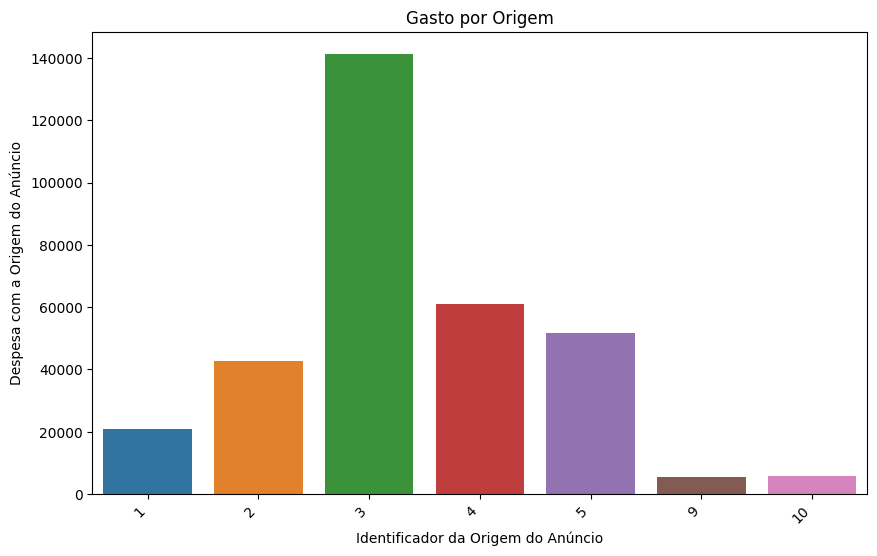

In [233]:
# Criando um gráfico de barras para o gasto por origem
plt.figure(figsize=(10,6))
sns.barplot(data=money_spend_per_source, x='source_id', y='costs')
plt.xticks(rotation=45, ha='right')
plt.title('Gasto por Origem')
plt.xlabel('Identificador da Origem do Anúncio')
plt.ylabel('Despesa com a Origem do Anúncio')
plt.show()

Podemos observar no gráfico de barras acima que a origem do anúncio com identificador 3 possui uma despesa muito mais alta em relação às outras origens, sendo essa despesa de 141321.63. Já o identificador da origem do anúncio que ocupa a segunda posição em relação às despesas é o 4, com 61073.60, ou seja, em torno de 2,3 vezes a menos que a despesa do identificador cque ocupa a liderança. Além disso, podemos reparar que as origens 9 e 10 tem gastos semelhantes entre si (5517.49 e 5822.49, respectivamente), sendo essas origens com os menores gastos. Dessa forma, calcularemos o ROI para verificar se os investimentos valeram a pena.

In [234]:
# Calculando quanto de dinheiro foi gasto ao longo do tempo
costs_df['costs_month'] = costs_df['dt'].dt.to_period('M')
money_spend_over_time = costs_df.groupby('costs_month')['costs'].sum().reset_index()
print(money_spend_over_time)

   costs_month     costs
0      2017-06  18015.00
1      2017-07  18240.59
2      2017-08  14790.54
3      2017-09  24368.91
4      2017-10  36322.88
5      2017-11  37907.88
6      2017-12  38315.35
7      2018-01  33518.52
8      2018-02  32723.03
9      2018-03  30415.27
10     2018-04  22289.38
11     2018-05  22224.27


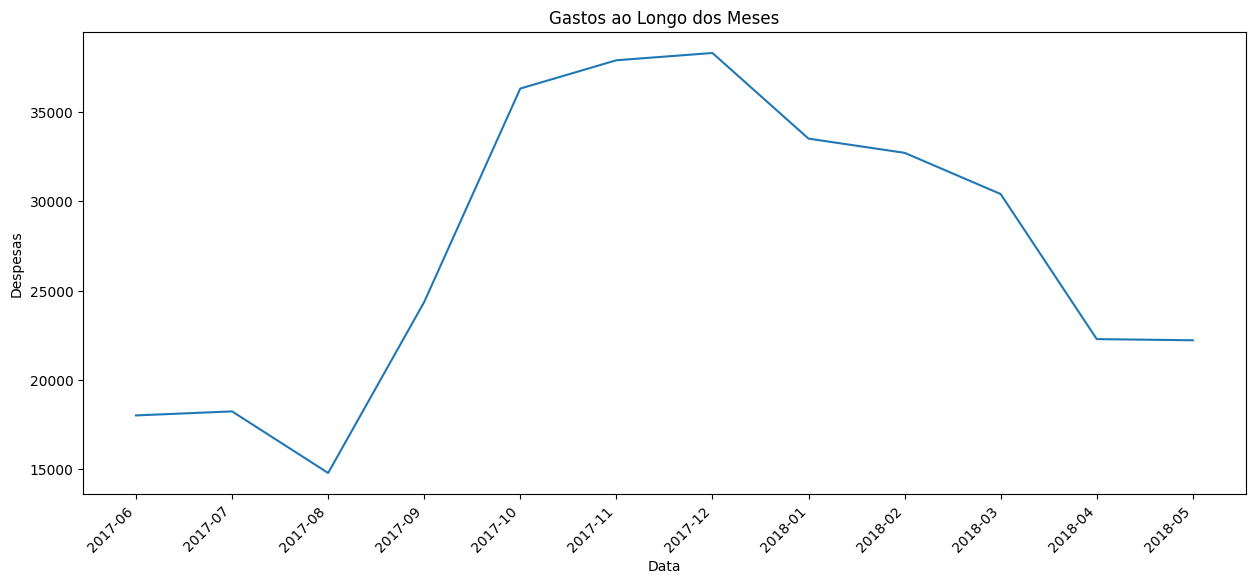

In [235]:
# Criando um gráfico de linhas para o gasto ao longo do tempo
money_spend_over_time['costs_month'] = money_spend_over_time['costs_month'].astype('str')
plt.figure(figsize=(15, 6))
sns.lineplot(data=money_spend_over_time, x='costs_month', y='costs')
plt.xticks(rotation=45, ha='right')
plt.title('Gastos ao Longo dos Meses')
plt.xlabel('Data')
plt.ylabel('Despesas')
plt.show()

Podemos observar no gráfico de linhas que as despesas começam em torno de 18.000 (junho de 2017), caem em agosto de 2017 para em torno de 14.790, sendo esse mês com a despesa mais baixa. A partir de agosto os gastos voltam a subir, atingindo o pico em dezembro de 2017, com despesa em torno de 38.315. Em seguida, as despesas caem até maio de 2018, com em torno de 22.224. Dessa forma, concluímos que o período de agosto de 2017 a dezembro de 2017 apresentou um grande crescimento nos gastos, sendo dezembro com em torno de 2,6 vezes mais gastos que em agosto. Uma hipótese para o aumento das despesas de marketing no período de agosto a dezembro é que o final do ano apresenta várias datas comemorativas nos EUA (Thanksgiving, Natal etc) e por isso as empresas tendem a aumentar os investimentos em marketing antes dessas datas. Essa análise leva em conta o dataset americano.

In [236]:
# Unindo o DataFrame first_visit_per_user e valid_sessions pelas colunas uid e start_ts
merge_first_visit_valid_session = first_visit_per_user.merge(valid_sessions, on=['uid', 'start_ts'])
print(merge_first_visit_valid_session)

                         uid            start_ts   cohort   device  \
0             11863502262781 2018-03-01 17:27:00  2018-03    touch   
1             49537067089222 2018-02-06 15:55:00  2018-02    touch   
2            297729379853735 2017-06-07 18:47:00  2017-06  desktop   
3            313578113262317 2017-09-18 22:49:00  2017-09  desktop   
4            325320750514679 2017-09-30 14:29:00  2017-09  desktop   
...                      ...                 ...      ...      ...   
207046  18446316582013423015 2018-02-26 10:14:00  2018-02  desktop   
207047  18446403737806311543 2017-11-30 03:36:00  2017-11  desktop   
207048  18446556406699109058 2018-01-01 16:29:00  2018-01    touch   
207049  18446621818809592527 2017-12-27 13:27:00  2017-12  desktop   
207050  18446676030785672386 2017-10-04 16:01:00  2017-10  desktop   

                    end_ts source_id session_day  session_week  session_month  \
0      2018-03-01 17:33:00         3  2018-03-01             9              3 

In [237]:
# Descobrindo quantos clientes novos vieram de cada origem
new_clients_per_source = merge_first_visit_valid_session.groupby('source_id').agg({'uid': 'nunique'})
print(new_clients_per_source)

             uid
source_id       
1           9283
2          16401
3          59791
4          65234
5          44160
6              2
7             31
9           5955
10          6194


In [238]:
# Unindo os DataFrames money_spend_per_source e new_clients_per_source pela coluna source_id
merge_money_spend_new_clients_per_source = money_spend_per_source.merge(new_clients_per_source, on='source_id')
print(merge_money_spend_new_clients_per_source)

   source_id      costs    uid
0          1   20833.27   9283
1          2   42806.04  16401
2          3  141321.63  59791
3          4   61073.60  65234
4          5   51757.10  44160
5          9    5517.49   5955
6         10    5822.49   6194


In [239]:
# Calculando o CAC por origem
merge_money_spend_new_clients_per_source['cac'] = merge_money_spend_new_clients_per_source['costs'] / merge_money_spend_new_clients_per_source['uid']
print(merge_money_spend_new_clients_per_source.set_index('source_id')['cac'])

source_id
1     2.244239
2     2.609965
3     2.363594
4     0.936223
5     1.172036
9     0.926531
10    0.940021
Name: cac, dtype: float64


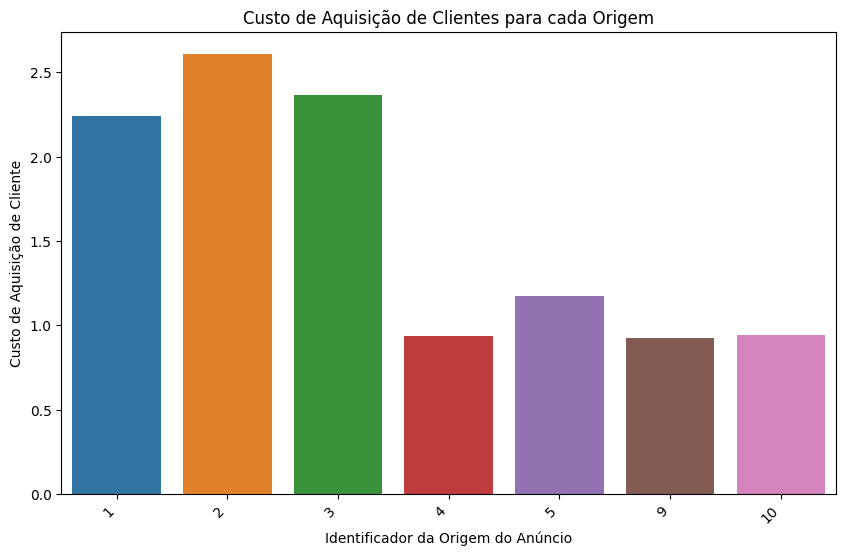

In [240]:
# Criando um gráfico de barras com os custos da aquisição de clientes para cada origem
plt.figure(figsize=(10,6))
sns.barplot(data=merge_money_spend_new_clients_per_source, x='source_id', y='cac')
plt.xticks(rotation=45, ha='right')
plt.title('Custo de Aquisição de Clientes para cada Origem')
plt.xlabel('Identificador da Origem do Anúncio')
plt.ylabel('Custo de Aquisição de Cliente')
plt.show()

<div class="alert alert-block alert-success">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Resolvido: o <b>CAC por origem</b> agora está calculado e visualizado (origens 4 e 5 com o menor custo de aquisição, ≈ 0,94 e 1,17). Boa base para comparar com o retorno.
</div>

O gráfico de barras acima ilustra quanto custa para a empresa para atrair um novo cliente, ou seja, o CAC (Custo de Aquisição de Clientes) representa quanto a empresa gastou para conquistar cada novo cliente. Dessa forma, vemos que o identificador de origem do anúncio 2 possui o maior custo para atrair um cliente, sendo esse valor em torno de 2.61. O segundo idenficador com maior gasto é o 3, sendo em torno de 2.36. Em terceiro lugar vem o identificador da origem 1, com uma despesa em torno de 2.24. O identificador 9 tem o menor custo para atrair um novo cliente, sendo esse valor em torno de 0.927. Os identificadores 4 e 10 tem um gasto parecido com o do identificador 9, sendo em torno de 0.936 e 0.94, respectivamente. Além disso, o identificador 5 possui a quarta maior despesa para atrair um cliente, sendo em torno de 1.17. Conforme visualizamos acima, a origem 3 gasta muito mais que a origem 2 com marketing, mas o CAC da origem 3 é menor que o CAC da origem 2, ou seja, a origem 3 gasta mais no total (141.321,63), mas atrai proporcionalmente ainda mais clientes (59.791), o que faz o CAC dela ser menor que o da origem 2. Ademais, a origem 2 tem o maior CAC (2,61) e uma despesa total menor, e a origem 3 tem o segundo maior CAC (2,36) mas atrai muito mais clientes. Sendo assim, um CAC alto não é necessariamente ruim se o LTV do cliente também for alto. Vimos que a origem 4 atraiu 65.234 clientes com um CAC em torno de 0.94, enquanto as origens 9 e 10 atraíram apenas em torno de 6.000 clientes cada, o que significa que a origem 4 tem o melhor equilíbrio entre escala e custo e por isso é muito vantajosa. 

In [241]:
# Unindo os DataFrames merge_first_visit_valid_session e orders_df pela coluna uid para encontrar o LTV por origem
visits_orders_df = merge_first_visit_valid_session.merge(orders_df, on='uid')
print(visits_orders_df)

                        uid            start_ts   cohort   device  \
0           313578113262317 2017-09-18 22:49:00  2017-09  desktop   
1          1575281904278712 2017-06-03 10:13:00  2017-06    touch   
2          1575281904278712 2017-06-03 10:13:00  2017-06    touch   
3          2429014661409475 2017-10-11 17:14:00  2017-10  desktop   
4          2464366381792757 2018-01-27 20:10:00  2018-01  desktop   
...                     ...                 ...      ...      ...   
49936  18445407535914413204 2017-09-22 23:48:00  2017-09  desktop   
49937  18445407535914413204 2017-09-22 23:48:00  2017-09  desktop   
49938  18445601152732270159 2017-08-07 11:51:00  2017-08  desktop   
49939  18446156210226471712 2017-11-07 10:01:00  2017-11  desktop   
49940  18446167067214817906 2017-10-17 10:05:00  2017-10  desktop   

                   end_ts source_id session_day  session_week  session_month  \
0     2017-09-18 23:07:00         2  2017-09-18            38              9   
1     2017-

In [242]:
# Calculando a soma da receita por origem
revenue_users_per_source = visits_orders_df.groupby('source_id').agg({'revenue': 'sum', 'uid': 'nunique'})
print(revenue_users_per_source)

            revenue    uid
source_id                 
1          30537.37   2964
2          47265.19   3515
3          53061.62  10248
4          55601.15  10113
5          53352.23   6847
6              0.00      0
7              1.22      1
9           5746.85   1087
10          4611.73   1306


In [243]:
# Calculando o LTV por origem
revenue_users_per_source['ltv_source'] = revenue_users_per_source['revenue'] / revenue_users_per_source['uid']
print(revenue_users_per_source['ltv_source'])

source_id
1     10.302756
2     13.446711
3      5.177754
4      5.497988
5      7.792059
6           NaN
7      1.220000
9      5.286891
10     3.531187
Name: ltv_source, dtype: float64


Verificamos que a origem 6 tem 0 usuários e 0 receita, o que retorna NaN ao fazer o cálculo de LTV por origem.

In [244]:
# Unindo os DataFrames revenue_users_per_source e merge_money_spend_new_clients_per_source para calcular o ROI
valid_revenue_users_per_source = revenue_users_per_source.reset_index()
revenue_costs_per_source = valid_revenue_users_per_source.merge(merge_money_spend_new_clients_per_source, on='source_id')
print(revenue_costs_per_source)

   source_id   revenue  uid_x  ltv_source      costs  uid_y       cac
0          1  30537.37   2964   10.302756   20833.27   9283  2.244239
1          2  47265.19   3515   13.446711   42806.04  16401  2.609965
2          3  53061.62  10248    5.177754  141321.63  59791  2.363594
3          4  55601.15  10113    5.497988   61073.60  65234  0.936223
4          5  53352.23   6847    7.792059   51757.10  44160  1.172036
5          9   5746.85   1087    5.286891    5517.49   5955  0.926531
6         10   4611.73   1306    3.531187    5822.49   6194  0.940021


In [245]:
# Calculando o ROI
revenue_costs_per_source['roi'] = (revenue_costs_per_source['ltv_source'] - revenue_costs_per_source['cac']) / revenue_costs_per_source['cac']
print(revenue_costs_per_source.set_index('source_id')['roi'])

source_id
1     3.590757
2     4.152065
3     1.190628
4     4.872517
5     5.648312
9     4.706115
10    2.756498
Name: roi, dtype: float64


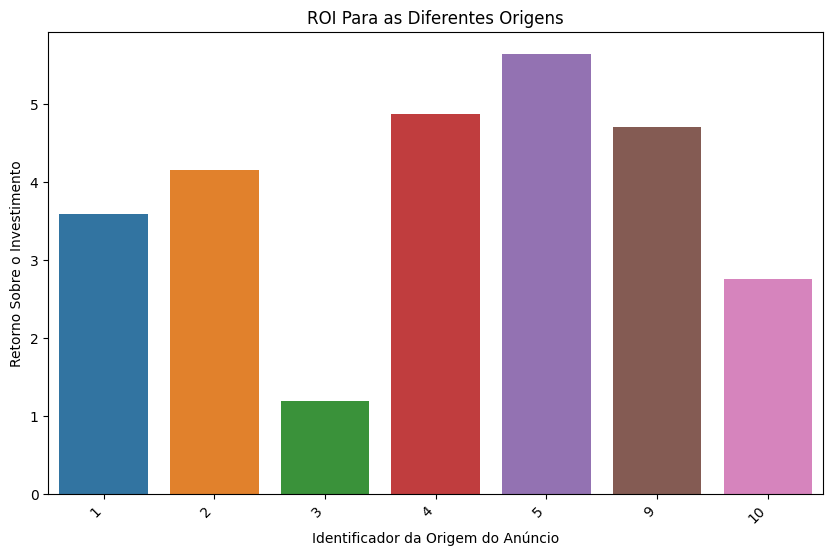

In [246]:
# Construindo um gráfico de barras para comparar o ROI entre as diferentes origens
plt.figure(figsize=(10,6))
sns.barplot(data=revenue_costs_per_source, x='source_id', y='roi')
plt.xticks(rotation=45, ha='right')
plt.title('ROI Para as Diferentes Origens')
plt.xlabel('Identificador da Origem do Anúncio')
plt.ylabel('Retorno Sobre o Investimento')
plt.show()

<div class="alert alert-block alert-success">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Marketing completo! O <b>ROI/ROMI por origem</b> mostra quais fontes se pagam melhor (origens 4 e 5 com os maiores retornos, ≈ 4,9 e 5,6; origem 3 a menos rentável, ≈ 1,2). É exatamente a informação que orienta a realocação do orçamento — fecha muito bem a análise.
</div>

Em relação à análise geral de marketing, concluímos que no total foi gasto 329131.62. Descobrimos também que a origem 3 possui uma despesa muito mais alta em relação às outras origens, sendo essa despesa de 141321.63. O segundo lugar de maior gasto foi ocupado pela origem 4, com 61073.60, ou seja, em torno de 2,3 vezes menor que a despesa do identificador com maior despesa. Ademais, inferimos que as origens 9 e 10 tem gastos semelhantes entre si (5517.49 e 5822.49, respectivamente), sendo essas origens com os menores gastos. Por meio do gráfico de linhas, que mostra os gastos ao longo dos meses, analisamos que o período de agosto de 2017 a dezembro de 2017 apresentou um grande crescimento nos gastos, sendo agosto em torno de 14.790 e dezembro em torno de 38.315, ou seja, dezembro apresenta em torno de 2,6 vezes mais gastos que agosto. Uma hipótese para o aumento das despesas de marketing no período de agosto a dezembro é que o final do ano apresenta várias datas comemorativas nos EUA (Thanksgiving, Natal etc) e por isso as empresas tendem a aumentar os investimentos em marketing antes dessas datas. Essa análise leva em conta o dataset americano. Além disso, verificamos, por meio do gráfico do CAC (Custo de Aquisição de Clientes), que o identificador de origem do anúncio 2 possui o maior custo para atrair um cliente, sendo esse valor em torno de 2.61. O segundo idenficador com maior gasto é o 3, sendo em torno de 2.36. Em terceiro lugar vem o identificador da origem 1, com uma despesa em torno de 2.24. O identificador 9 tem o menor custo para atrair um novo cliente, sendo esse valor em torno de 0.927. Os identificadores 4 e 10 tem um gasto parecido com o do identificador 9, sendo em torno de 0.936 e 0.94, respectivamente. Além disso, o identificador 5 possui a quarta maior despesa para atrair um cliente, sendo em torno de 1.17. Dessa forma, inferimos que a origem 3 gasta muito mais que a origem 2 com marketing, mas o CAC da origem 3 é menor que o CAC da origem 2, ou seja, a origem 3 gasta mais no total, mas atrai proporcionalmente ainda mais clientes, o que faz o CAC dela ser menor que o da origem 2. Sendo assim, um CAC alto não é necessariamente ruim se o LTV do cliente também for alto. Vimos que a origem 4 atraiu 65.234 clientes com um CAC em torno de 0.94, enquanto as origens 9 e 10 atraíram apenas em torno de 6.000 clientes cada, o que significa que a origem 4 tem o melhor equilíbrio entre escala e custo e por isso é muito vantajosa. 
Ademais, verificamos que todas as origens tiveram o ROI (Retorno Sobre Investimento) maior do que 0, concluindo que o investimento valeu a pena e todas as origens obtiveram lucro. No gráfico acima, podemos inferir que o identificador de origem 5 teve o maior ROI, sendo em torno de 5.65. O segundo maior ROI foi o do identificador 4, em torno de 4.87. O identificador 9 teve um ROI bem próximo ao 4, sendo em torno de 4.71. O quarto maior ROI foi do identificador 2, em torno de 4.15, e a quinta posição foi do identificador 1, em torno de 3.59. O pior ROI foi do identificador 3, com uma média de 1.19. Além disso, a segunda pior posição foi do identificador 10, com o ROI de 2.76. 
Por fim, concluímos que a origem 2 tem o maior LTV ( em torno de 13.45) e a origem 1 o segundo maior ( em torno de 10.30). Assim como a origem 2 teve o maior LTV, teve também o maior CAC (cerca de 2.61), por isso o seu ROI não foi tão alto, já que ao mesmo tempo que tem um número grande no numerador (LTV) há também um valor alto no denominador (CAC), sendo ROI = (LTV - CAC)/CAC.
A origem 5 mesmo apresentando um LTV (em torno de 7.79) menor que a origem 2, também apresentou um CAC (1.17) menor que a origem 2, o que gerou um ROI maior na origem 5 (o maior de todos) do que na origem 2.
Como já havia sido concluído anteriormente, a origem 3 teve o maior gasto total de marketing, cerca de 141.321 e agora pudemos analisar que essa mesma origem teve o pior ROI, sugerindo que seria melhor reduzir os investimentos nessa origem. Vale mencionar também a origem 9, que apresentou o terceiro maior ROI (em torno de 4.71) e o menor CAC de todos (em torno de 0.93), porém atraiu poucos clientes (em torno de 5955). Isso pode ser explicado porque ela recebeu muito menos investimento (em torno de 5517) comparado com a origem 4 (61073) e com a origem 5 (51757). Assim, a origem 9 pode ser uma oportunidade escondida e, dessa forma, se aumentássemos o investimento nela poderíamos atrair mais clientes. 
A origem 10, apesar do segundo pior ROI (2.76) apresentou um dos CAC's mais baixos (em torno de 0.94), o que é um ponto positivo, e um dos menores gastos (em torno de 5822). Dessa forma, a situação da origem 10 é menos preocupante que da origem 3 e como o investimento nessa origem já é baixo vale manter, já que um ROI de 2.76 (maior que 0) ainda significa que gera lucro.
Sendo assim, devemos focar mais os investimentos na origem 4 (segundo maior ROI ( em torno de 4.87) + maior número de clientes (65.234) + CAC baixo (em torno de 0.94)), na origem 5 (maior ROI (em torno de 5.65)) e na origem 9.

# Passo 3: Conclusão
Por meio das análises dos dados da Y.Afisha podemos concluir que as origens 4, 5 e 9 merecem mais focos nos investimentos. A origem 4, por apresentar o segundo maior ROI (Retorno Sobre Investimento), em torno de 4.87, o maior número de clientes (65.234), um LTV em torno de 5.50 e um CAC (Custo de Aquisição de Cliente) baixo (em torno de 0.94), representa uma fonte com potencial forte para atrair clientes e dar retorno sobre o investimento. Esses valores significam que para cada cliente, que custou 0.94 para atrair, a empresa recebeu 5.50, o que é um bom negócio.
Além disso, a origem 5, apresentou o terceiro LTV (total de dinheiro que um cliente traz para a empresa) mais alto, em torno de 7.79, e um CAC baixo (1.17), o que gerou um ROI maior na origem 5 (o maior de todos), valendo focar os investimentos nessa origem. Já a origem 9 apresentou o terceiro maior ROI (em torno de 4.71) e o menor CAC de todos (em torno de 0.93), porém atraiu poucos clientes (em torno de 5955). Isso pode ser explicado porque ela recebeu muito menos investimento (em torno de 5517) comparado com a origem 4 (61073) e com a origem 5 (51757). Assim, a origem 9 pode ser uma oportunidade escondida e, dessa forma, se aumentássemos o investimento nessa origem poderíamos atrair mais clientes. 
Ademais, a origem 3 teve o maior gasto total de marketing, cerca de 141.321 e analisamos que essa mesma origem teve o pior ROI, sugerindo que seria melhor reduzir os investimentos nessa origem, que estavam altos. A origem 10, apesar do segundo pior ROI (2.76) apresentou um dos CAC's mais baixos (em torno de 0.94), o que é um ponto positivo, e um dos menores gastos (em torno de 5822). Dessa forma, a situação da origem 10 é menos preocupante que da origem 3 e como o investimento nessa origem já é baixo vale mantê-lo, já que um ROI de 2.76 (maior que 0) ainda significa que gera lucro. Em relação às origens 1 e 2, inferimos que o LTV dos dois é alto, sendo em torno de 10.30 e 13.45, respectivamente. Além disso, o CAC dos dois também é alto, sendo de 2.24 e 2.61, respectivamente. Assim, o LTV é suficiente para cobrir o CAC de cada um, apresentando um ROI maior que 0, sendo cerca de 3.59 para a origem 1 e 4.15 para a origem 2, o que faz a origem 1 ocupar a quinta posição de ROI e a origem 2 a quarta. Dessa forma, vale manter os investimentos nas origens 1 e 2.